In [609]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler,  FunctionTransformer, RobustScaler
from sklearn.pipeline import Pipeline

from scipy import stats

from tqdm import tqdm
import statistics
import shap
import optuna
import logging
optuna.logging.set_verbosity(optuna.logging.ERROR)



from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, \
AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier, RidgeClassifier, ElasticNet, LogisticRegression, LinearRegression
from catboost import CatBoostClassifier


from sklearn.model_selection import train_test_split, cross_val_score \
,GridSearchCV, KFold, RepeatedKFold, StratifiedKFold, ShuffleSplit, StratifiedShuffleSplit \
, RandomizedSearchCV

from sklearn.metrics import roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
xgb.set_config(verbosity=0)

# Define the problem and analyze it from a broader perspective

## 1. Define the objective in business terms

The goal of the project is to develop a machine learning model to predict whether an applicant is approved for a loan, which will help banks and financial institutions make better loan decisions.

## 2. Describe how your solution will be used
My solution will be used as a real estate price prediction system and can be implemented in several forms, such as:

* a web application
* an API
* an analytical dashboard
* a reporting module
* integration with mobile applications

## 3. Identify existing solutions or workarounds (if any)
#### Traditional valuation methods:

* Rule based system
* Classical statistical scoring
* Scorecards

---

#### Existing technological solutions:

* Hybrid decision engines
* Alternative data scoring
* Real-time decisioning

## 4. In which categories should the problem be defined (unsupervised/supervised, incremental/static, etc.)?

* **Learning:** supervised
* **Prediction type:** classification (binary: approve / reject), optionally regression (probability of default, PD)
* **Learning mode:** initially static, later incremental / periodically retrained
* **Type of data:** tabular (core), optionally temporal (transaction history, behavioral trends) and geospatial (location stability, regional risk)

## 5. How will the model's performance be measured?
The results are evaluated using area under the ROC curve using the predicted probabilities and the ground truth targets.

## 6. Is the performance measurement linked to the business objective?

The business objective is to develop a model that helps any financial institutions or banks with their decision-making in approving loans.
Model performance is evaluated using the ROC curve and the Area Under the ROC Curve (AUC), which directly reflects the model’s ability to distinguish between creditworthy and non-creditworthy applicants across all decision thresholds.
ROC-based evaluation directly supports risk-based lending decisions and portfolio profitability.

## 7. What is the minimum performance required to meet the business objective?

The minimum required performance is an ROC AUC ≥ 0.65, ensuring sufficient class separation to support risk-based credit decisions across operating points on the ROC curve.

## 8. Are there any comparable problems? Can you leverage existing experience or tools?

The problem is comparable to standard credit scoring and PD modeling tasks, where ROC/AUC-based evaluation, established modeling techniques, and mature tooling are already widely used and can be directly leveraged.

#### Tools:
* **Machine learning:** well-established statistical and machine learning models

## 9. Can you get help from experts?
No

## 10. How can the problem be solved manually?

The problem can be addressed manually through expert-driven credit assessment using predefined rules and analyst judgment, but this approach is not scalable and lacks consistent risk ranking compared to ROC-based model evaluation.

## 11. Make a list of assumptions established by you (or others)
#### Assumptions regarding the data:

* **Availability of historical data:** It is assumed that there is a sufficient amount of historical data about previous loans of a person.
* **High data quality:** It is assumed that the data does not contain significant gaps, errors, or anomalies. In case of missing values, it is assumed they can be filled using interpolation, medians, or other imputation techniques.
* **Consistency of units:** All data is measured in consistent units (e.g., person income in USD, person employment lenght in months).

---

#### **Assumptions regarding the model:**

* **Classification model:** It is assumed that the model will be a classification model, as the goal is to predict a binary outcome (approve/reject) or the probability of default.
* **Model simplicity at the beginning:** Initially, simpler and interpretable models will be used (e.g., logistic regression, decision trees) as a baseline. If these models do not achieve sufficient performance, more advanced methods such as gradient boosting (XGBoost, LightGBM) or neural networks may be applied.
* **Model stability:** The model is expected to maintain stable and consistent discrimination (as measured by ROC/AUC) on new, unseen data. Proper validation techniques such as cross-validation, hold-out sets, and back-testing will be applied.

---

#### **Assumptions regarding model performance:**

* **Expected discrimination level:** It is assumed that the model will achieve a ROC AUC sufficient for business needs, e.g., AUC ≥ 0.65, ensuring meaningful separation between creditworthy and non-creditworthy applicants..
* **Expected speed of operation:** The model should be fast enough for real-time decisioning, allowing instant credit approval decisions (e.g., for online loan applications).
* **Regular model updates:** The model will require periodic retraining or recalibration on new data to adapt to changing borrower behavior, economic conditions, and portfolio risk.
* **Stability across segments:** The model is expected to maintain consistent performance across customer segments and products, avoiding bias or degradation in specific subgroups.
* **Compliance and monitoring:** The model’s performance metrics (AUC, ROC) will be monitored continuously, ensuring alignment with business objectives and regulatory requirements.

# Data acquisition

## 1. Specify the type and amount of data needed
The provided data is in CSV format , separated to test and train set. Train set contains 58645 rows and 13 columns and the Test set contains 39098 rows and  12 columns. There is also an extension to train set with additional 32581 rows.

## 2. Identify the source from which you can obtain the data and document it
https://www.kaggle.com/competitions/playground-series-s4e10/data

https://www.kaggle.com/datasets/chilledwanker/loan-approval-prediction

## 3. Check how much storage space will be needed to store the data
The data requires less than 10 MB of disk space.

## 4. Acquire the data and convert it into a format that allows easy manipulation (without changing the essence of the data), and ensure that sensitive data has been removed or secured (e.g., masked).

In [483]:
df_train = pd.read_csv('../data/raw/train.csv')
df_test = pd.read_csv('../data/raw/test.csv')
credit_risk_dataset = pd.read_csv('../data/raw/credit_risk_dataset.csv')

In [484]:
df_train.iloc[0].values

array([0, 37, 35000, 'RENT', 0.0, 'EDUCATION', 'B', 6000, 11.49, 0.17,
       'N', 14, 0], dtype=object)

## 5. Check the size and type of the data

In [485]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [486]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39098 entries, 0 to 39097
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39098 non-null  int64  
 1   person_age                  39098 non-null  int64  
 2   person_income               39098 non-null  int64  
 3   person_home_ownership       39098 non-null  object 
 4   person_emp_length           39098 non-null  float64
 5   loan_intent                 39098 non-null  object 
 6   loan_grade                  39098 non-null  object 
 7   loan_amnt                   39098 non-null  int64  
 8   loan_int_rate               39098 non-null  float64
 9   loan_percent_income         39098 non-null  float64
 10  cb_person_default_on_file   39098 non-null  object 
 11  cb_person_cred_hist_length  39098 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.6+ MB


In [487]:
credit_risk_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


## 6. Split the test set

In [488]:
df_test = pd.read_csv('../data/raw/test.csv')
df_test.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,58645,23,69000,RENT,3.0,HOMEIMPROVEMENT,F,25000,15.76,0.36,N,2
1,58646,26,96000,MORTGAGE,6.0,PERSONAL,C,10000,12.68,0.10,Y,4
2,58647,26,30000,RENT,5.0,VENTURE,E,4000,17.19,0.13,Y,2
3,58648,33,50000,RENT,4.0,DEBTCONSOLIDATION,A,7000,8.90,0.14,N,7
4,58649,26,102000,MORTGAGE,8.0,HOMEIMPROVEMENT,D,15000,16.32,0.15,Y,4


## 7. Combine sets

In [489]:
credit_risk_dataset['id'] = list(range(0,len(credit_risk_dataset)))
full_train_df = pd.concat([df_train,credit_risk_dataset], axis=0).reset_index(drop=True)
full_train_df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


# Data analysis

## 1. Create a copy of the data being analyzed (resampling it to a reasonable size if necessary)

In [490]:
df_train_copy = full_train_df.copy()
df_test_copy = df_test.copy()

## 2. For supervised learning tasks, identify the target attribute

In [491]:
#Target feature
df_train_copy[['loan_status']].head()

,loan_status
0,0
1,0
2,0
3,0
4,0


In [492]:
df_train_copy['loan_status'].value_counts()

loan_status
0    75768
1    15458
Name: count, dtype: int64

In [493]:
df_train_copy['loan_status'] = df_train_copy['loan_status'].astype('category')

## 3. Identify each attribute and its parameters

In [494]:
df_train.columns

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

* **id:** A unique identifier for each loan application or borrower.

* **person_age:** The age of the individual applying for the loan(years).

* **person_income:** The annual income of the borrower(USD).

* **person_home_ownership:** The type of home tenure(RENT, MORTGAGE, OWN, OTHER)

* **person_emp_length:** Number of years the individual has been employed(years).

* **loan_intent:** The purpose of the loan(EDUCATION, MEDICAL, PERSONAL, VENTURE, DEBTCONSOLODATION, HOMEIMPROVEMENT)

* **loan_grade:** A risk score assigned to the loan based on the borrower's creditworthiness(A, B, C, D, E, F, G)

* **loan_amnt:** The total amount of money requested for the loan(USD).

* **loan_int_rate:** The interest rate associated with the loan(%).

* **loan_percent_income:** The ratio of the loan amount to the borrower's annual income(%).

* **cb_person_default_on_file:** Indicates if the person has a history of default (Y/N).

* **cb_person_credit_hist_length:** The length of the individual's credit history(years).

* **loan_status:** The target variable: whether the loan was approved/repaid (0/1)

In [495]:
#divide dataset to get numerical and categorical data
def num_cat_divider(df):
    numerical = df.select_dtypes(include='number').drop('id', axis=1)
    categorical = df.select_dtypes(exclude='number')
    return numerical, categorical

numerical, categorical = num_cat_divider(df_train_copy)

In [496]:
#create outliers detector
def outliers_detection(df, columns):
    outliers = []
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # std= df[column].std()
        # mean= df[column].mean()
        # outlier_data= df[(df[column] > mean + 2 * std) |
        #                  (df[column] < mean - 2 * std)]

        outlier_data = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outliers.append(outlier_data[column].count())
    return outliers

In [497]:
#describe numerical and categorical data
class DataDescriber:
    def __init__(self,df,specs):
        self.df = df
        self.specs = specs
        self.data = None
        self.num_features = self.df.select_dtypes(include=['number']).drop('id', axis=1)
        self.cat_features = self.df.select_dtypes(exclude='number')
        
        if self.specs == 'numerical':
            self.numerical_describer()
        elif self.specs == 'categorical':
            self.categorical_describer()
        elif self.specs == 'full':
            self.full_describer()


    def numerical_describer(self):
        num_data_desc = pd.DataFrame(index=list(self.num_features))
        num_data_desc['type'] = self.num_features.dtypes
        num_data_desc['count'] = self.num_features.count()
        num_data_desc['nunique'] = self.num_features.nunique()
        num_data_desc['%unique'] = num_data_desc['nunique'] / len(self.num_features) * 100
        num_data_desc['null'] = self.num_features.isnull().sum()
        num_data_desc['%null'] = num_data_desc['null'] / len(self.num_features) * 100
        num_data_desc['min'] = self.num_features.min()
        num_data_desc['max'] = self.num_features.max()
        num_data_desc['mean'] = self.num_features.mean()
        num_data_desc['median'] = self.num_features.median()
        num_data_desc['std'] = self.num_features.std()
        num_data_desc['outliers'] = outliers_detection(self.df,list(self.num_features))
        num_data_desc['%outliers'] = num_data_desc['outliers'] / len(self.num_features) * 100
        self.data = num_data_desc
        return num_data_desc
        
    def categorical_describer(self):
        cat_data_desc = pd.DataFrame(index = list(self.cat_features))
        cat_data_desc['type'] = self.cat_features.dtypes
        cat_data_desc['count'] = self.cat_features.count()
        cat_data_desc['nunique'] = self.cat_features.nunique()
        cat_data_desc['%unique'] = cat_data_desc['nunique'] / len(self.cat_features) * 100
        cat_data_desc['null'] = self.cat_features.isnull().sum()
        cat_data_desc['%null'] = cat_data_desc['null'] / len(self.cat_features) * 100
        self.data = cat_data_desc
        return cat_data_desc
        
    def full_describer(self):
        cols_to_concat = ['type','count','nunique','%unique','null','%null']
        num_df = self.numerical_describer()
        cat_df = self.categorical_describer()
        num_cat_data_described = pd.concat((num_df[cols_to_concat],cat_df[cols_to_concat]), axis=0)
        self.data = num_cat_data_described

    def show_data(self):
        return self.data

In [498]:
#show described numerical data
num_data_described = DataDescriber(df_train_copy, 'numerical').show_data()
num_data_described

,type,count,nunique,%unique,null,%null,min,max,mean,median,std,outliers,%outliers
person_age,int64,91226,58,0.063578,0,0.000000,20.00,144.00,27.616480,26.00,6.148115,3940,4.318944
person_income,int64,91226,4376,4.796878,0,0.000000,4000.00,6000000.00,64770.706224,57000.00,47936.961097,3546,3.887050
person_emp_length,float64,90331,38,0.041655,895,0.981080,0.00,123.00,4.732119,4.00,4.025068,2127,2.331572
loan_amnt,int64,91226,759,0.832000,0,0.000000,500.00,35000.00,9350.348607,8000.00,5848.605423,3794,4.158902
loan_int_rate,float64,88110,388,0.425317,3116,3.415693,5.42,23.22,10.789508,10.95,3.108998,49,0.053713
loan_percent_income,float64,91226,78,0.085502,0,0.000000,0.00,0.83,0.163154,0.14,0.097491,1768,1.938044
cb_person_cred_hist_length,int64,91226,29,0.031789,0,0.000000,2.00,30.00,5.810219,4.00,4.038412,3135,3.436520


In [499]:
# show described categorical data
cat_data_described = DataDescriber(df_train_copy, 'categorical').show_data()
cat_data_described 

,type,count,nunique,%unique,null,%null
person_home_ownership,object,91226,4,0.004385,0,0.0
loan_intent,object,91226,6,0.006577,0,0.0
loan_grade,object,91226,7,0.007673,0,0.0
cb_person_default_on_file,object,91226,2,0.002192,0,0.0
loan_status,category,91226,2,0.002192,0,0.0


In [500]:
#show described both numerical and categorical data
num_cat_data_described = DataDescriber(df_train_copy,'full').show_data()
num_cat_data_described

,type,count,nunique,%unique,null,%null
person_age,int64,91226,58,0.063578,0,0.000000
person_income,int64,91226,4376,4.796878,0,0.000000
person_emp_length,float64,90331,38,0.041655,895,0.981080
loan_amnt,int64,91226,759,0.832000,0,0.000000
loan_int_rate,float64,88110,388,0.425317,3116,3.415693
loan_percent_income,float64,91226,78,0.085502,0,0.000000
cb_person_cred_hist_length,int64,91226,29,0.031789,0,0.000000
person_home_ownership,object,91226,4,0.004385,0,0.000000
loan_intent,object,91226,6,0.006577,0,0.000000
loan_grade,object,91226,7,0.007673,0,0.000000


## 4. Visualize the data

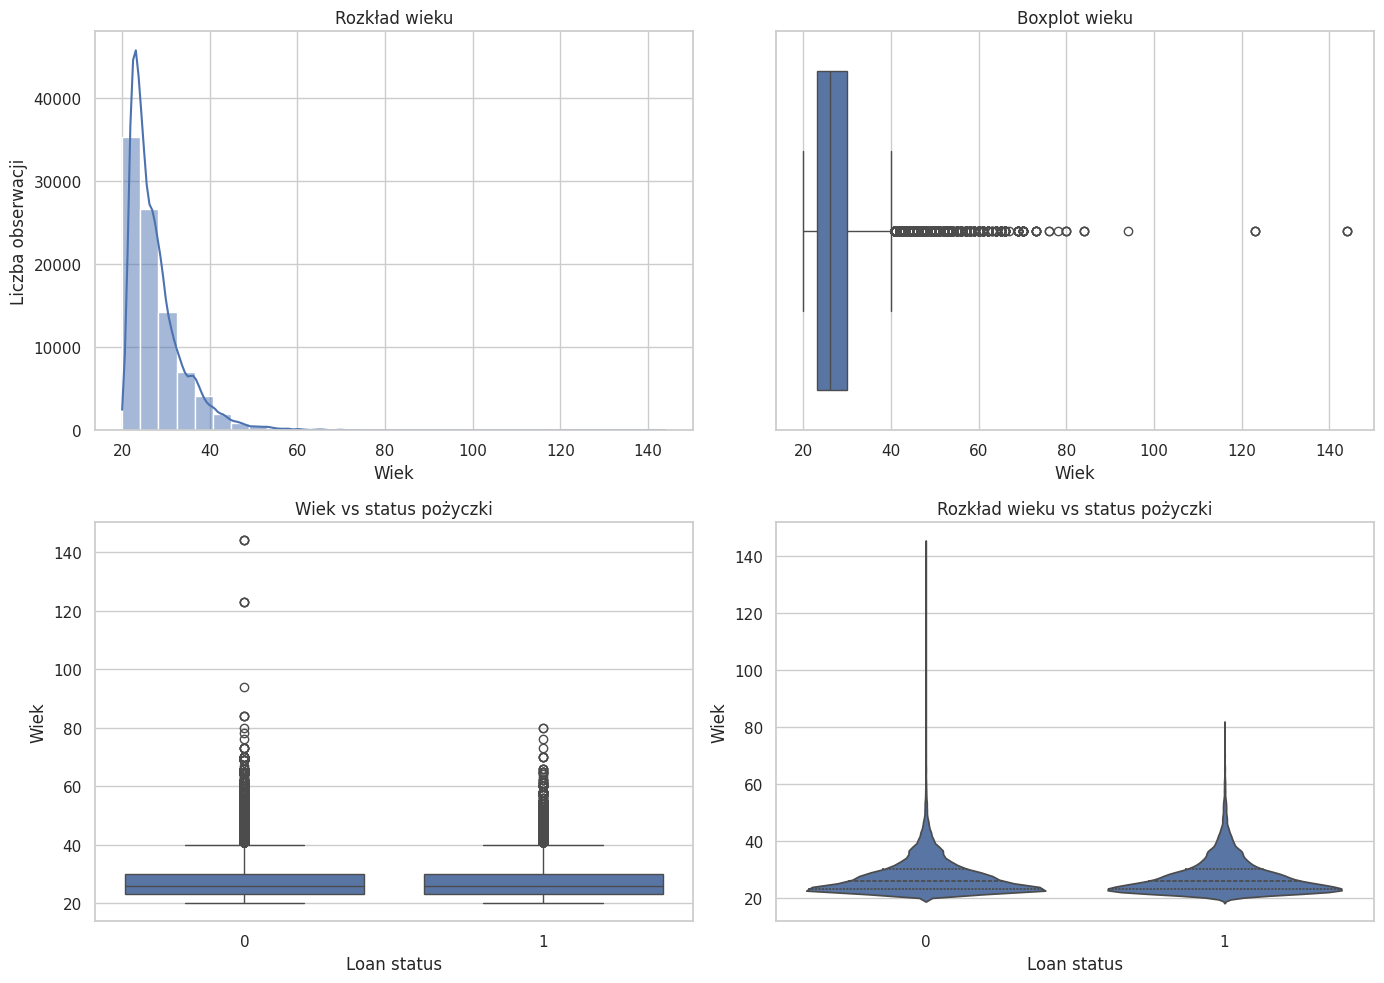

In [501]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1️⃣ Histogram – rozkład wieku
sns.histplot(df_train_copy["person_age"], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Rozkład wieku")
axes[0, 0].set_xlabel("Wiek")
axes[0, 0].set_ylabel("Liczba obserwacji")

# 2️⃣ Boxplot – outliery
sns.boxplot(x=df_train_copy["person_age"], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot wieku")
axes[0, 1].set_xlabel("Wiek")

# 3️⃣ Boxplot: age vs loan_status
sns.boxplot(x="loan_status", y="person_age", data=df_train_copy, ax=axes[1, 0])
axes[1, 0].set_title("Wiek vs status pożyczki")
axes[1, 0].set_xlabel("Loan status")
axes[1, 0].set_ylabel("Wiek")

# 4️⃣ Violin plot: age vs loan_status
sns.violinplot(
    x="loan_status",
    y="person_age",
    data=df_train_copy,
    inner="quart",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Rozkład wieku vs status pożyczki")
axes[1, 1].set_xlabel("Loan status")
axes[1, 1].set_ylabel("Wiek")

plt.tight_layout()
plt.show()

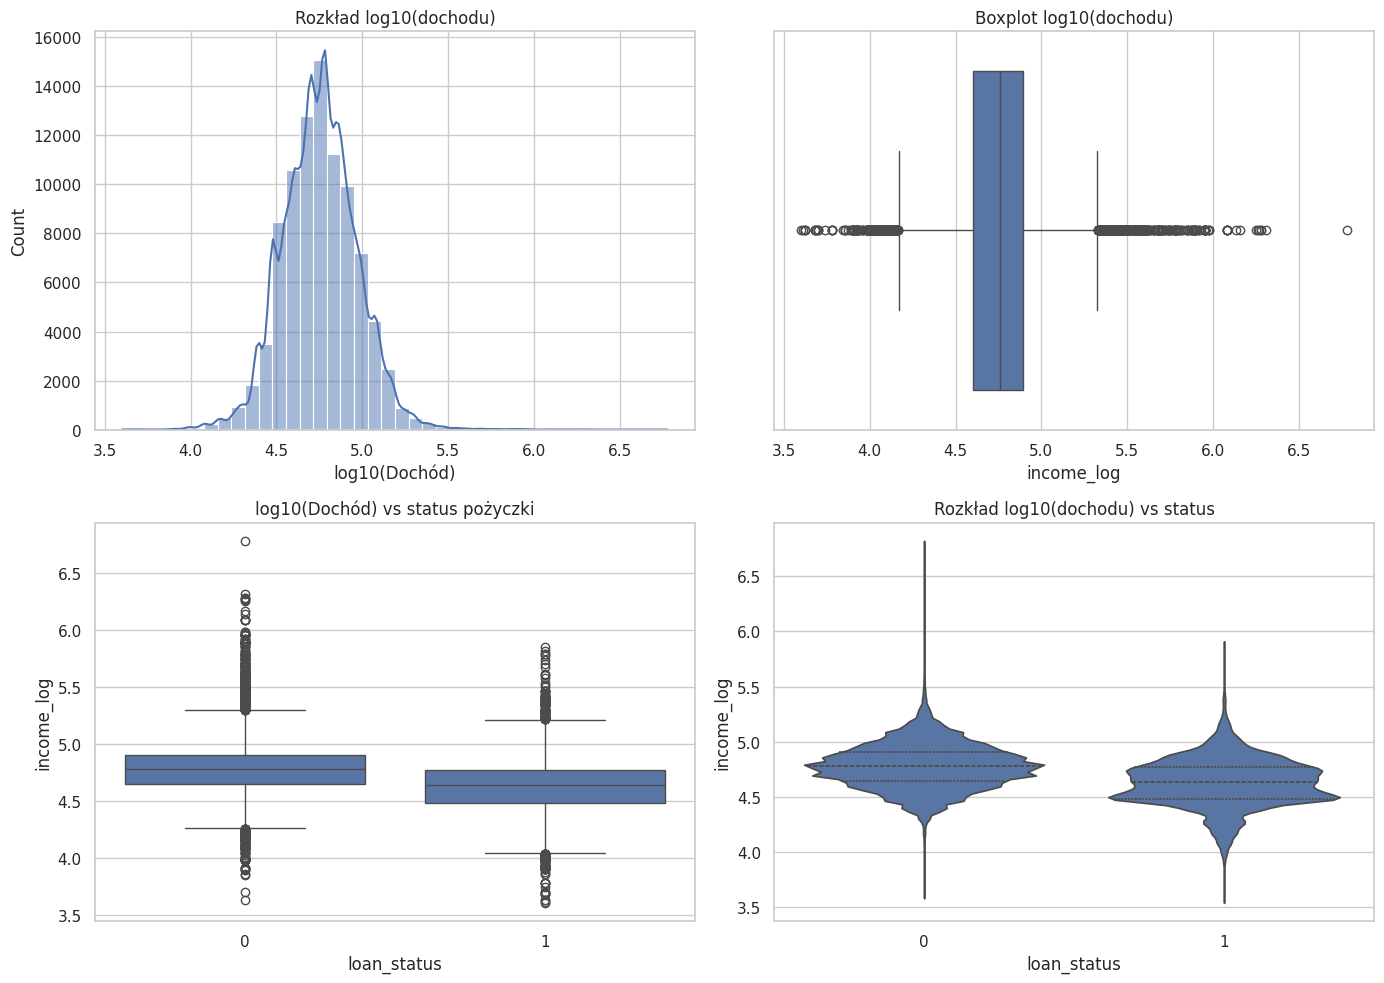

In [502]:
df_train_copy["income_log"] = np.log10(df_train_copy["person_income"])
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1️⃣ Histogram (log-transformed data)
sns.histplot(df_train_copy["income_log"], bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Rozkład log10(dochodu)")
axes[0, 0].set_xlabel("log10(Dochód)")

# 2️⃣ Boxplot
sns.boxplot(x=df_train_copy["income_log"], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot log10(dochodu)")

# 3️⃣ Boxplot vs target
sns.boxplot(
    x="loan_status",
    y="income_log",
    data=df_train_copy,
    ax=axes[1, 0]
)
axes[1, 0].set_title("log10(Dochód) vs status pożyczki")

# 4️⃣ Violin (TERAZ MA SENS)
sns.violinplot(
    x="loan_status",
    y="income_log",
    data=df_train_copy,
    inner="quart",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Rozkład log10(dochodu) vs status")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(
    data=df_train_copy,
    x="person_home_ownership",
    order=df_train_copy["person_home_ownership"].value_counts().index,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Liczebność kategorii – home ownership")
axes[0, 0].set_xlabel("Typ własności")
axes[0, 0].set_ylabel("Liczba obserwacji")

share = df_train_copy["person_home_ownership"].value_counts(normalize=True).mul(100)

sns.barplot(
    x=share.index,
    y=share.values,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Udział procentowy kategorii")
axes[0, 1].set_xlabel("Typ własności")
axes[0, 1].set_ylabel("Udział [%]")


ct = pd.crosstab(
    df_train_copy["person_home_ownership"],
    df_train_copy["loan_status"],
    normalize="index"
)

ct.plot(
    kind="bar",
    stacked=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Struktura loan_status w kategoriach")
axes[1, 0].set_xlabel("Typ własności")
axes[1, 0].set_ylabel("Udział")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(
    df_train_copy["person_emp_length"],
    bins=15,
    discrete=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Histogram stażu pracy")
axes[0, 0].set_xlabel("Lata zatrudnienia")
axes[0, 0].set_ylabel("Liczba obserwacji")


sns.countplot(
    data=df_train_copy,
    x="person_emp_length",
    order=sorted(df_train_copy["person_emp_length"].dropna().unique()),
    ax=axes[0, 1]
)
axes[0, 1].set_title("Liczebność wg stażu pracy")
axes[0, 1].set_xlabel("Lata zatrudnienia")
axes[0, 1].set_ylabel("Liczba obserwacji")
axes[0, 1].tick_params(axis="x", rotation=45)


sns.boxplot(
    x=df_train_copy["person_emp_length"],
    ax=axes[0, 2]
)
axes[0, 2].set_title("Boxplot stażu pracy")
axes[0, 2].set_xlabel("Lata zatrudnienia")


sns.boxplot(
    x="loan_status",
    y="person_emp_length",
    data=df_train_copy,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Staż pracy vs status pożyczki")
axes[1, 0].set_xlabel("Loan status")
axes[1, 0].set_ylabel("Lata zatrudnienia")


rate = (
    df_train_copy
    .assign(default=df_train_copy["loan_status"].astype(int))
    .groupby("person_emp_length")["default"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=rate,
    x="person_emp_length",
    y="default",
    marker="o",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Default rate vs staż pracy")
axes[1, 1].set_xlabel("Lata zatrudnienia")
axes[1, 1].set_ylabel("Default rate")

sns.barplot(
    data=rate,
    x="person_emp_length",
    y="default",
    ax=axes[1, 2]
)
axes[1, 2].set_title("Default rate vs staż pracy (bar)")
axes[1, 2].set_xlabel("Lata zatrudnienia")
axes[1, 2].set_ylabel("Default rate")
axes[1, 2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.countplot(
    data=df_train_copy,
    x="loan_intent",
    order=df_train_copy["loan_intent"].value_counts().index,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Liczebność wg loan_intent")
axes[0, 0].set_xlabel("Cel pożyczki")
axes[0, 0].set_ylabel("Liczba obserwacji")
axes[0, 0].tick_params(axis="x", rotation=45)


share = df_train_copy["loan_intent"].value_counts(normalize=True).mul(100)

sns.barplot(
    x=share.index,
    y=share.values,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Udział procentowy celów pożyczki")
axes[0, 1].set_xlabel("Cel pożyczki")
axes[0, 1].set_ylabel("Udział [%]")
axes[0, 1].tick_params(axis="x", rotation=45)


rate = (
    df_train_copy
    .assign(default=df_train_copy["loan_status"].astype(int))
    .groupby("loan_intent")["default"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=rate,
    x="loan_intent",
    y="default",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Default rate wg celu pożyczki")
axes[1, 0].set_xlabel("Cel pożyczki")
axes[1, 0].set_ylabel("Default rate")
axes[1, 0].tick_params(axis="x", rotation=45)


ct = pd.crosstab(
    df_train_copy["loan_intent"],
    df_train_copy["loan_status"],
    normalize="index"
)

ct.plot(
    kind="bar",
    stacked=True,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Struktura loan_status wg celu pożyczki")
axes[1, 1].set_xlabel("Cel pożyczki")
axes[1, 1].set_ylabel("Udział")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
grade_order = ["A", "B", "C", "D", "E", "F", "G"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.countplot(
    data=df_train_copy,
    x="loan_grade",
    order=grade_order,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Liczebność wg loan_grade")
axes[0, 0].set_xlabel("Grade")
axes[0, 0].set_ylabel("Liczba obserwacji")


rate = (
    df_train_copy
    .assign(default=df_train_copy["loan_status"].astype(int))
    .groupby("loan_grade")["default"]
    .mean()
    .reindex(grade_order)
    .reset_index()
)

sns.lineplot(
    data=rate,
    x="loan_grade",
    y="default",
    marker="o",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Default rate vs loan_grade")
axes[0, 1].set_xlabel("Grade")
axes[0, 1].set_ylabel("Default rate")


sns.barplot(
    data=rate,
    x="loan_grade",
    y="default",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Default rate vs loan_grade (bar)")
axes[1, 0].set_xlabel("Grade")
axes[1, 0].set_ylabel("Default rate")


ct = pd.crosstab(
    df_train_copy["loan_grade"],
    df_train_copy["loan_status"],
    normalize="index"
).reindex(grade_order)

ct.plot(
    kind="bar",
    stacked=True,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Struktura loan_status wg loan_grade")
axes[1, 1].set_xlabel("Grade")
axes[1, 1].set_ylabel("Udział")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.histplot(
    df_train_copy["loan_amnt"],
    bins=40,
    ax=axes[0, 0]
)
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("Rozkład kwoty pożyczki (log)")
axes[0, 0].set_xlabel("Loan amount [USD, log]")
axes[0, 0].set_ylabel("Liczba obserwacji")


sns.boxplot(
    x=df_train_copy["loan_amnt"],
    ax=axes[0, 1]
)
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Boxplot kwoty pożyczki (log)")
axes[0, 1].set_xlabel("Loan amount [USD, log]")


sns.boxplot(
    x="loan_status",
    y="loan_amnt",
    data=df_train_copy,
    ax=axes[1, 0]
)
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Kwota pożyczki vs status")
axes[1, 0].set_xlabel("Loan status")
axes[1, 0].set_ylabel("Loan amount [USD, log]")


sns.scatterplot(
    data=df_train_copy,
    x="person_income",
    y="loan_amnt",
    hue="loan_status",
    alpha=0.4,
    ax=axes[1, 1]
)
axes[1, 1].set_xscale("log")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Loan amount vs income (log-log)")
axes[1, 1].set_xlabel("Income [USD, log]")
axes[1, 1].set_ylabel("Loan amount [USD, log]")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.histplot(
    df_train_copy["loan_int_rate"],
    bins=30,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Rozkład oprocentowania pożyczki")
axes[0, 0].set_xlabel("Interest rate [%]")
axes[0, 0].set_ylabel("Liczba obserwacji")


sns.boxplot(
    x=df_train_copy["loan_int_rate"],
    ax=axes[0, 1]
)
axes[0, 1].set_title("Boxplot oprocentowania")
axes[0, 1].set_xlabel("Interest rate [%]")


sns.boxplot(
    x="loan_status",
    y="loan_int_rate",
    data=df_train_copy,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Oprocentowanie vs status pożyczki")
axes[1, 0].set_xlabel("Loan status")
axes[1, 0].set_ylabel("Interest rate [%]")


sns.kdeplot(
    data=df_train_copy,
    x="loan_int_rate",
    hue="loan_status",
    fill=True,
    common_norm=False,
    alpha=0.4,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Gęstość oprocentowania wg statusu")
axes[1, 1].set_xlabel("Interest rate [%]")
axes[1, 1].set_ylabel("Density")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.histplot(
    df_train_copy["loan_percent_income"],
    bins=30,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Rozkład loan_percent_income")
axes[0, 0].set_xlabel("Loan % of income")
axes[0, 0].set_ylabel("Liczba obserwacji")


sns.boxplot(
    x=df_train_copy["loan_percent_income"],
    ax=axes[0, 1]
)
axes[0, 1].set_title("Boxplot loan_percent_income")
axes[0, 1].set_xlabel("Loan % of income")


sns.boxplot(
    x="loan_status",
    y="loan_percent_income",
    data=df_train_copy,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Loan % of income vs status")
axes[1, 0].set_xlabel("Loan status")
axes[1, 0].set_ylabel("Loan % of income")


df_train_copy["lpi_bin"] = pd.qcut(
    df_train_copy["loan_percent_income"],
    q=10,
    duplicates="drop"
)

rate = (
    df_train_copy
    .assign(default=df_train_copy["loan_status"].astype(int))
    .groupby("lpi_bin")["default"]
    .mean()
    .reset_index()
)


plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))


sns.countplot(
    data=df_train_copy,
    x="cb_person_default_on_file",
    order=["N", "Y"],
    ax=axes[0]
)
axes[0].set_title("Liczebność: default on file")
axes[0].set_xlabel("Previous default")
axes[0].set_ylabel("Liczba obserwacji")


rate = (
    df_train_copy
    .assign(default=df_train_copy["loan_status"].astype(int))
    .groupby("cb_person_default_on_file")["default"]
    .mean()
    .reindex(["N", "Y"])
    .reset_index()
)

sns.barplot(
    data=rate,
    x="cb_person_default_on_file",
    y="default",
    ax=axes[1]
)
axes[1].set_title("Default rate: Y vs N")
axes[1].set_xlabel("Previous default")
axes[1].set_ylabel("Default rate")


ct = pd.crosstab(
    df_train_copy["cb_person_default_on_file"],
    df_train_copy["loan_status"],
    normalize="index"
).reindex(["N", "Y"])

ct.plot(
    kind="bar",
    stacked=True,
    ax=axes[2]
)
axes[2].set_title("Struktura loan_status")
axes[2].set_xlabel("Previous default")
axes[2].set_ylabel("Udział")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.histplot(
    df_train_copy["cb_person_cred_hist_length"],
    bins=30,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Rozkład długości historii kredytowej")
axes[0, 0].set_xlabel("Lata historii kredytowej")
axes[0, 0].set_ylabel("Liczba obserwacji")


sns.boxplot(
    x=df_train_copy["cb_person_cred_hist_length"],
    ax=axes[0, 1]
)
axes[0, 1].set_title("Boxplot historii kredytowej")
axes[0, 1].set_xlabel("Lata historii kredytowej")


sns.boxplot(
    x="loan_status",
    y="cb_person_cred_hist_length",
    data=df_train_copy,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Historia kredytowa vs status")
axes[1, 0].set_xlabel("Loan status")
axes[1, 0].set_ylabel("Lata historii kredytowej")


df_train_copy["credit_hist_bin"] = pd.qcut(
    df_train_copy["cb_person_cred_hist_length"],
    q=10,
    duplicates="drop"
)

rate = (
    df_train_copy
    .assign(default=df_train_copy["loan_status"].astype(int))
    .groupby("credit_hist_bin")["default"]
    .mean()
    .reset_index()
)


plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.countplot(
    data=df_train_copy,
    x="loan_status",
    order=[0, 1],
    ax=ax
)

ax.set_title("Rozkład klas targetu (loan_status)")
ax.set_xlabel("Loan status (0 = non-default, 1 = default)")
ax.set_ylabel("Liczba obserwacji")

plt.tight_layout()
plt.show()

## 5. Analyze the correlations between attributes.

In [513]:
numerical.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')

In [514]:
categorical.columns

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file', 'loan_status'],
      dtype='object')

In [515]:
#check correlations (numerical)
num_corr = numerical.corr()

<Axes: >

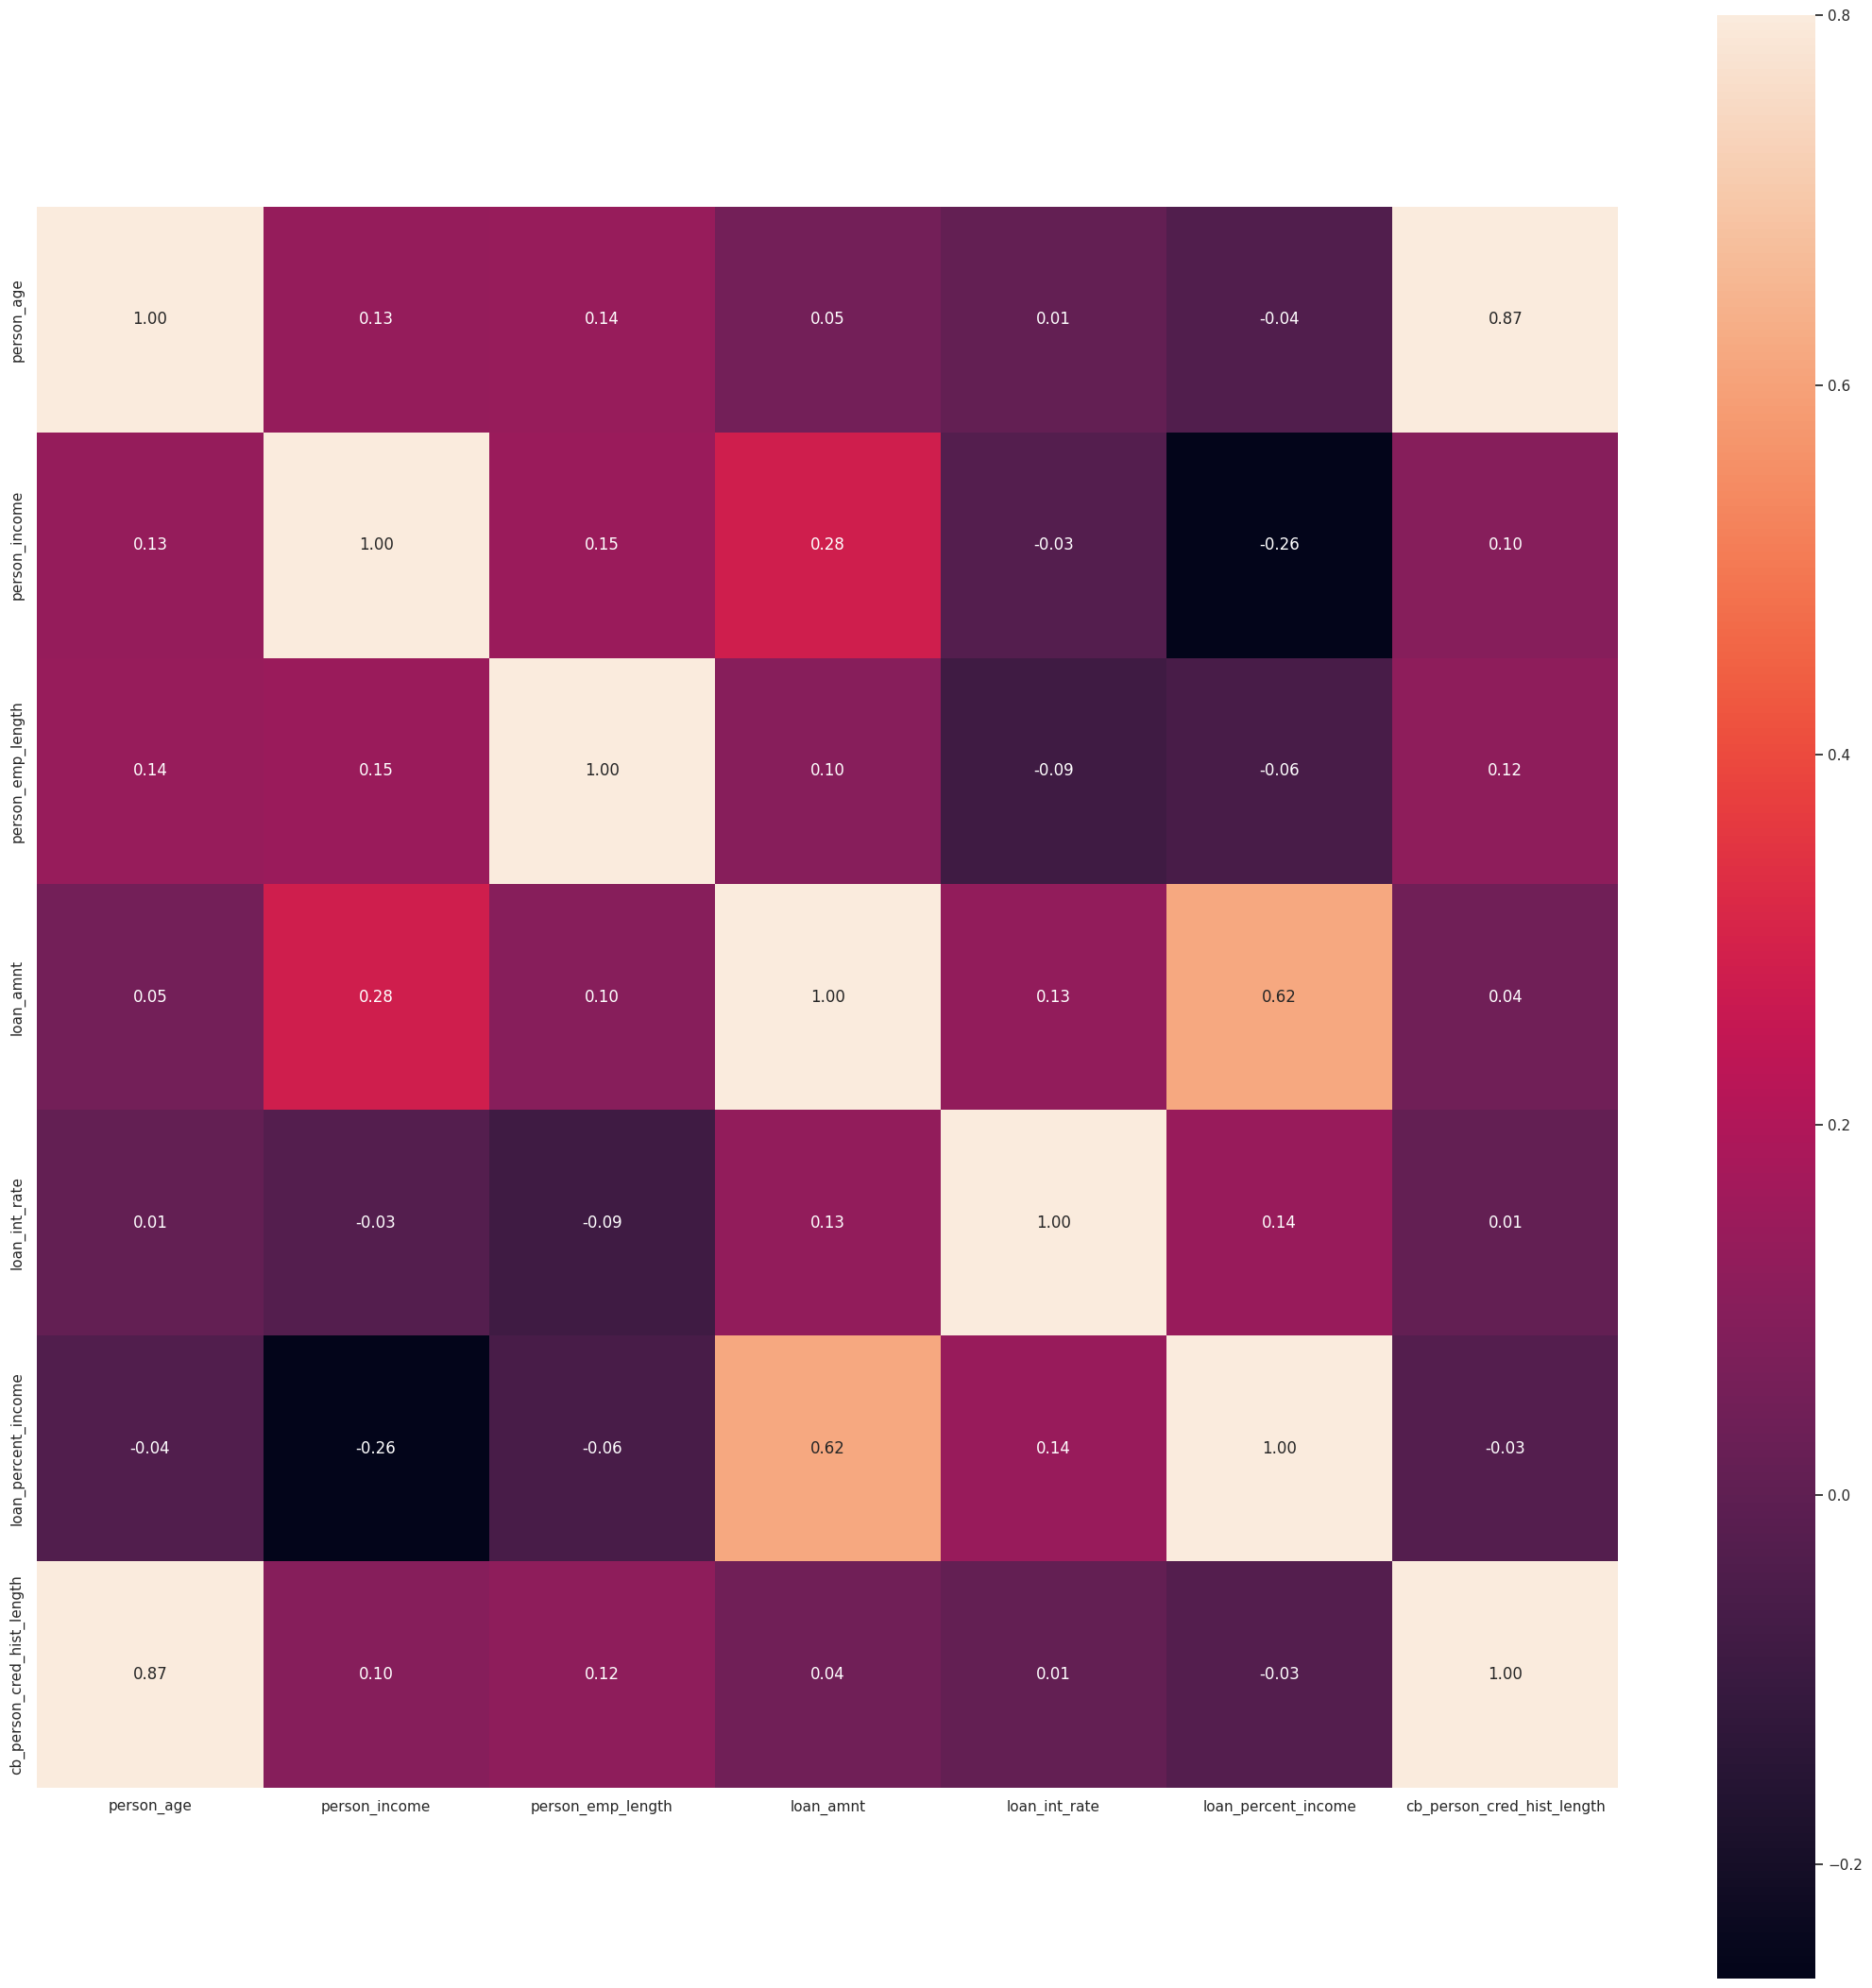

In [516]:
#numerical correlations matrix
f, ax = plt.subplots(figsize=(27,27))
sns.heatmap(num_corr, vmax=.8, square=True, annot=True, fmt='.2f')

In [517]:
#correlation with each other
corr_pairs = num_corr.abs().stack().reset_index()
corr_pairs.columns=['Feature 1','Feature 2','Correlation']
corr_pairs = corr_pairs[corr_pairs['Feature 1'] < corr_pairs['Feature 2']]
top_corr_pairs = corr_pairs.sort_values(by='Correlation', ascending=False)
top_corr_pairs.head(10)

,Feature 1,Feature 2,Correlation
42,cb_person_cred_hist_length,person_age,0.868351
26,loan_amnt,loan_percent_income,0.616053
22,loan_amnt,person_income,0.284271
36,loan_percent_income,person_income,0.261722
15,person_emp_length,person_income,0.146155
33,loan_int_rate,loan_percent_income,0.142105
2,person_age,person_emp_length,0.137030
1,person_age,person_income,0.133876
25,loan_amnt,loan_int_rate,0.127393
44,cb_person_cred_hist_length,person_emp_length,0.118002


In [518]:
#correlation with target feature
df_train_copy[numerical.columns.to_list()].corrwith(df_train_copy['loan_status'])

person_age                   -0.008058
person_income                -0.152001
person_emp_length            -0.091718
loan_amnt                     0.130323
loan_int_rate                 0.339932
loan_percent_income           0.381631
cb_person_cred_hist_length   -0.008049
dtype: float64

In [519]:
#correlation with target feature t-test
for col in numerical.columns.to_list():
    group0 = df_train_copy[df_train_copy['loan_status'] == 0][col]
    group1 = df_train_copy[df_train_copy['loan_status'] == 1][col]
    
    t_stat, p_value = stats.ttest_ind(group0, group1)
    print(f'{col}: t-stat = {t_stat:.3f}, p-value = {p_value:.3f}')

person_age: t-stat = 2.434, p-value = 0.015
person_income: t-stat = 46.449, p-value = 0.000
person_emp_length: t-stat = nan, p-value = nan
loan_amnt: t-stat = -39.700, p-value = 0.000
loan_int_rate: t-stat = nan, p-value = nan
loan_percent_income: t-stat = -124.703, p-value = 0.000
cb_person_cred_hist_length: t-stat = 2.431, p-value = 0.015


## 6. Check the linearity of features

In [520]:
#visualize linearity
# plt.figure(figsize=(30,150))
# plt.subplots_adjust(hspace=0.5, wspace=0.25)
# for n, col in enumerate(list(numerical)):
#     plt.subplot(20,3,n+1)
#     sns.regplot(data=df_train_copy, x= col, y= 'loan_status')
#     plt.title(col, fontsize=17)
# plt.show()

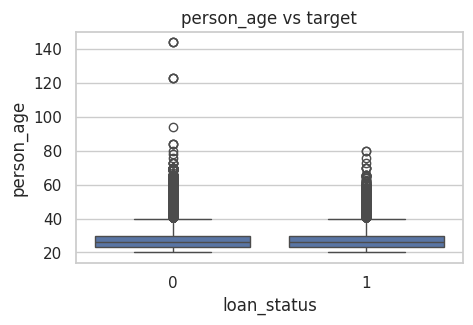

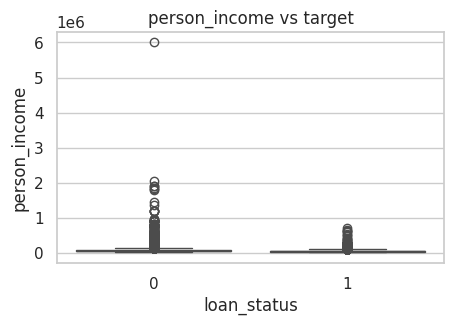

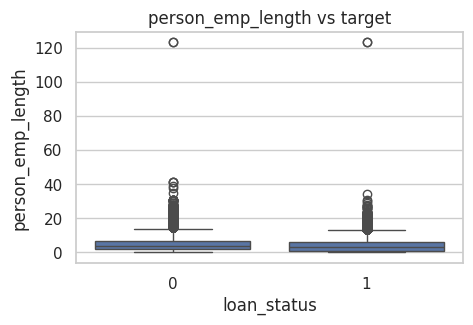

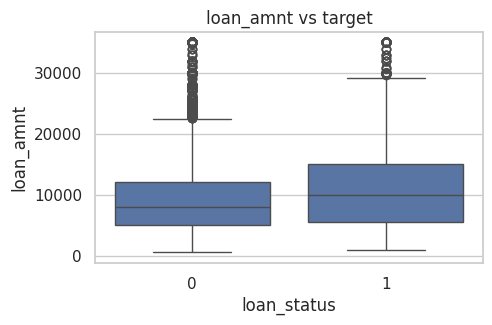

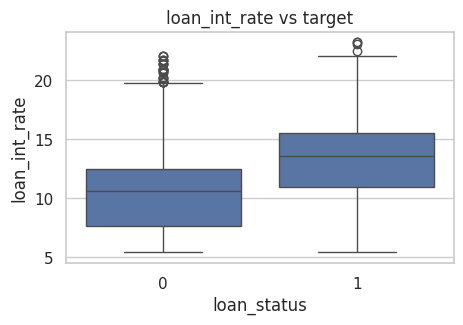

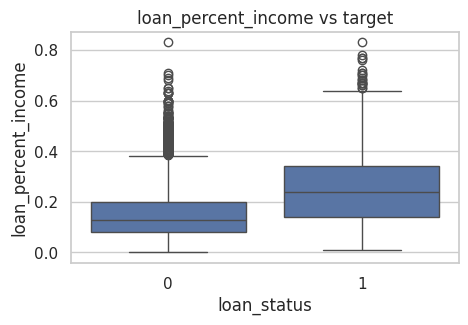

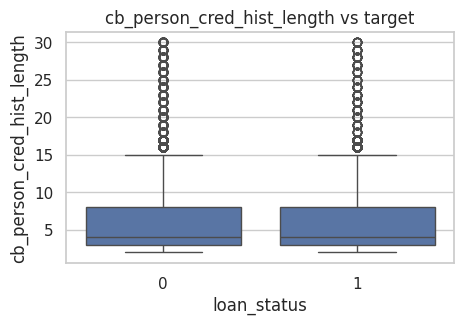

In [521]:
for col in numerical.columns.to_list():
    plt.figure(figsize=(5,3))
    sns.boxplot(x='loan_status', y=col, data=df_train_copy)
    plt.title(f'{col} vs target')
    plt.show()

## 7. Summary

* Few columns contain missing data. Features with a small number of missing values will be imputed.
* The distributions of some features are skewed — appropriate transformations will be applied.
* Some features are highly correlated — they will be combined into a single variable.
* Not all features exhibit linearity.
* There is a few weird outliers that will be analyzed and managed.

# Data preparation

In [522]:
df_train_to_clean = df_train_copy.drop(['income_log', 'lpi_bin', 'credit_hist_bin'], axis=1).copy(deep=True)
df_train_to_clean.shape

(91226, 13)

## 1. Data cleaning

### Outliers handling

In [523]:
df_train_to_clean[df_train_to_clean['person_age']>94]

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
47336,47336,123,36000,MORTGAGE,7.0,PERSONAL,B,6700,10.75,0.18,N,4,0
58726,81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0.02,N,3,0
58828,183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0.03,N,2,0
59220,575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0.25,N,3,0
59392,747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0.26,N,4,0
90942,32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0.00,N,25,0


In [524]:
df_train_to_clean = df_train_to_clean[df_train_to_clean['person_age'] <= 94]

In [525]:
df_train_to_clean[df_train_to_clean['person_emp_length']>50]

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
41079,41079,28,60350,MORTGAGE,123.0,MEDICAL,D,25000,15.95,0.35,Y,6,1
49252,49252,21,192000,MORTGAGE,123.0,VENTURE,B,20000,11.49,0.10,N,2,0
58645,0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,0.59,Y,3,1
58855,210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0.10,N,4,0


In [526]:
df_train_to_clean = df_train_to_clean[
    (df_train_to_clean['person_emp_length'].isna()) | 
    (df_train_to_clean['person_emp_length'] <= 100)] 

### Filling missing values

In [527]:
df_train_to_clean.isna().sum()

id                               0
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3115
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
loan_status                      0
dtype: int64

In [528]:
person_emp_length_missing = df_train_to_clean[df_train_to_clean['person_emp_length'].isna()]
person_emp_length_missing.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
58750,105,22,12600,MORTGAGE,NaN,PERSONAL,A,2000,5.42,0.16,N,4,1
58867,222,24,185000,MORTGAGE,NaN,EDUCATION,B,35000,12.42,0.19,N,2,0
59024,379,24,16800,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3900,NaN,0.23,N,3,1
59052,407,25,52000,RENT,NaN,PERSONAL,B,24000,10.74,0.46,N,2,1
59053,408,22,17352,MORTGAGE,NaN,EDUCATION,C,2250,15.27,0.13,Y,3,0


In [529]:
loan_int_rate_missing = df_train_to_clean[df_train_to_clean['loan_int_rate'].isna()]
loan_int_rate_missing.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
58684,39,23,71500,RENT,3.0,DEBTCONSOLIDATION,D,30000,NaN,0.42,N,4,1
58695,50,24,78000,RENT,4.0,DEBTCONSOLIDATION,D,30000,NaN,0.38,Y,4,1
58702,57,23,277000,OWN,3.0,PERSONAL,A,35000,NaN,0.13,N,4,0
58704,59,24,12000,OWN,2.0,VENTURE,E,1750,NaN,0.15,Y,3,0
58707,62,26,263000,MORTGAGE,0.0,EDUCATION,B,10000,NaN,0.04,N,4,1


***person_emp_length handling***

In [530]:
person_emp_length_mask = ~df_train_to_clean.isin(person_emp_length_missing.to_dict(orient='list')).all(axis=1)
person_emp_length_result = df_train_to_clean[person_emp_length_mask]
person_emp_length_result.isna().sum()

id                               0
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3047
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
loan_status                      0
dtype: int64

In [531]:
person_emp_length_features_train = person_emp_length_result[['person_age']]
person_emp_length_target_train = person_emp_length_result[['person_emp_length']]

person_emp_length_lin_reg = LinearRegression()
person_emp_length_lin_reg.fit(person_emp_length_features_train, person_emp_length_target_train)

LinearRegression()

In [532]:
person_emp_length_predictions = person_emp_length_lin_reg.predict(person_emp_length_missing[['person_age']])
person_emp_length_predicted_data = person_emp_length_missing.copy()
person_emp_length_predicted_data['person_emp_length']=person_emp_length_predictions.astype('int')
person_emp_length_predicted_data

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
58750,105,22,12600,MORTGAGE,4,PERSONAL,A,2000,5.42,0.16,N,4,1
58867,222,24,185000,MORTGAGE,4,EDUCATION,B,35000,12.42,0.19,N,2,0
59024,379,24,16800,MORTGAGE,4,DEBTCONSOLIDATION,A,3900,NaN,0.23,N,3,1
59052,407,25,52000,RENT,4,PERSONAL,B,24000,10.74,0.46,N,2,1
59053,408,22,17352,MORTGAGE,4,EDUCATION,C,2250,15.27,0.13,Y,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
90930,32285,38,12000,OWN,5,EDUCATION,A,4800,7.29,0.40,N,12,1
90973,32328,51,18408,RENT,6,PERSONAL,C,1000,14.65,0.05,Y,20,1
91005,32360,70,39996,RENT,8,MEDICAL,C,3600,15.23,0.09,Y,19,0
91098,32453,56,32400,RENT,7,MEDICAL,A,8575,7.51,0.26,N,18,0


In [533]:
df_train_to_clean.loc[df_train_to_clean['person_emp_length'].isna(),'person_emp_length'] = person_emp_length_predicted_data
df_train_to_clean.isna().sum()

id                               0
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3115
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
loan_status                      0
dtype: int64

***loan_int_rate handling***

In [534]:
loan_int_rate_mask = ~df_train_to_clean.isin(loan_int_rate_missing.to_dict(orient='list')).all(axis=1)
loan_int_rate_result = df_train_to_clean[loan_int_rate_mask]
loan_int_rate_result.isna().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [535]:
loan_int_rate_features_train = loan_int_rate_result[['loan_amnt']]
loan_int_rate_target_train = loan_int_rate_result[['loan_int_rate']]

loan_int_rate_lin_reg = LinearRegression()
loan_int_rate_lin_reg.fit(loan_int_rate_features_train, loan_int_rate_target_train)

LinearRegression()

In [536]:
loan_int_rate_predictions = loan_int_rate_lin_reg.predict(loan_int_rate_missing[['loan_amnt']])
loan_int_rate_predicted_data = loan_int_rate_missing.copy()
loan_int_rate_predicted_data['loan_int_rate']=loan_int_rate_predictions
loan_int_rate_predicted_data

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
58684,39,23,71500,RENT,3.0,DEBTCONSOLIDATION,D,30000,12.192831,0.42,N,4,1
58695,50,24,78000,RENT,4.0,DEBTCONSOLIDATION,D,30000,12.192831,0.38,Y,4,1
58702,57,23,277000,OWN,3.0,PERSONAL,A,35000,12.532482,0.13,N,4,0
58704,59,24,12000,OWN,2.0,VENTURE,E,1750,10.273802,0.15,Y,3,0
58707,62,26,263000,MORTGAGE,0.0,EDUCATION,B,10000,10.834227,0.04,N,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91192,32547,53,4888,OWN,0.0,VENTURE,C,1400,10.250027,0.29,Y,28,1
91197,32552,65,45900,RENT,2.0,EDUCATION,C,10000,10.834227,0.22,Y,19,0
91198,32553,54,20000,RENT,2.0,MEDICAL,C,5000,10.494576,0.25,N,28,0
91214,32569,51,60000,MORTGAGE,1.0,PERSONAL,A,7500,10.664401,0.13,N,23,0


In [537]:
df_train_to_clean.loc[df_train_to_clean['loan_int_rate'].isna(),'loan_int_rate'] = loan_int_rate_predicted_data
df_train_to_clean.isna().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

## 2. Combine features and create new ones(feature engineering)

In [538]:
df_train_cleaned = df_train_to_clean.copy(deep=True)

### Add New Features

In [539]:
#new features
df_train_cleaned["loan_to_income"] = df_train_cleaned["loan_amnt"] / df_train_cleaned["person_income"]
df_train_cleaned["income_per_age"] = df_train_cleaned["person_income"] / df_train_cleaned["person_age"]
df_train_cleaned["high_loan_burden"] = (df_train_cleaned["loan_percent_income"] > 0.3).astype(int)
df_train_cleaned["emp_to_age_ratio"] = df_train_cleaned["person_emp_length"] / df_train_cleaned["person_age"]
df_train_cleaned["young_high_loan"] = ((df_train_cleaned["person_age"] < 25) & (df_train_cleaned["loan_percent_income"] > 0.4)).astype(int)
df_train_cleaned["cred_hist_ratio"] = (df_train_cleaned["cb_person_cred_hist_length"] / df_train_cleaned["person_age"])
df_train_cleaned["thin_credit_history"] = (df_train_cleaned["cb_person_cred_hist_length"] < 3).astype(int)
df_train_cleaned["had_default"] = (df_train_cleaned["cb_person_default_on_file"] == "Y").astype(int)


In [540]:
#ordinal encoding
home_map = {"OWN": 3, "MORTGAGE": 2, "RENT": 1, "OTHER": 0}
df_train_cleaned["home_stability"] = df_train_cleaned["person_home_ownership"].map(home_map)

grade_map = {"A": 6, "B": 5, "C": 4, "D": 3, "E": 2, "F": 1, "G": 0}
df_train_cleaned["loan_grade_num"] = df_train_cleaned["loan_grade"].map(grade_map)

In [541]:
#for trees models
df_train_cleaned["grade_interest_interaction"] = (df_train_cleaned["loan_grade_num"] * df_train_cleaned["loan_int_rate"])
df_train_cleaned["income_grade"] = (df_train_cleaned["person_income"] * df_train_cleaned["loan_grade_num"])

In [542]:
#transformations
df_train_cleaned["log_income"] = np.log1p(df_train_cleaned["person_income"])
df_train_cleaned["log_loan_amnt"] = np.log1p(df_train_cleaned["loan_amnt"])

### Convert numerical features with a small number of unique values into categorical features

In [543]:
DataDescriber(df_train_cleaned, 'full').show_data().sort_values(['nunique'])

,type,count,nunique,%unique,null,%null
thin_credit_history,int64,91216,2,0.002193,0,0.0
had_default,int64,91216,2,0.002193,0,0.0
young_high_loan,int64,91216,2,0.002193,0,0.0
high_loan_burden,int64,91216,2,0.002193,0,0.0
cb_person_default_on_file,object,91216,2,0.002193,0,0.0
loan_status,category,91216,2,0.002193,0,0.0
home_stability,int64,91216,4,0.004385,0,0.0
person_home_ownership,object,91216,4,0.004385,0,0.0
loan_intent,object,91216,6,0.006578,0,0.0
loan_grade_num,int64,91216,7,0.007674,0,0.0


In [544]:
for col in df_train_cleaned.drop('loan_status', axis=1).select_dtypes(include='number'):
    if df_train_cleaned[col].nunique() <= 25:
        df_train_cleaned[col] = df_train_cleaned[col].astype('category')

In [545]:
object_cols = df_train_cleaned.select_dtypes(include='object').columns
df_train_cleaned[object_cols] = df_train_cleaned[object_cols].astype('category')

In [546]:
DataDescriber(df_train_cleaned, 'full').show_data().sort_values(['nunique'])

,type,count,nunique,%unique,null,%null
high_loan_burden,category,91216,2,0.002193,0,0.0
young_high_loan,category,91216,2,0.002193,0,0.0
had_default,category,91216,2,0.002193,0,0.0
thin_credit_history,category,91216,2,0.002193,0,0.0
cb_person_default_on_file,category,91216,2,0.002193,0,0.0
loan_status,category,91216,2,0.002193,0,0.0
person_home_ownership,category,91216,4,0.004385,0,0.0
home_stability,category,91216,4,0.004385,0,0.0
loan_intent,category,91216,6,0.006578,0,0.0
loan_grade,category,91216,7,0.007674,0,0.0


### One-Hot encode categorical features

In [547]:
df_train_cleaned.shape

(91216, 27)

In [548]:
df_encoded = pd.get_dummies(df_train_cleaned, columns=['loan_intent'], drop_first=False)
df_encoded.shape

(91216, 32)

### Encode labels

In [549]:
df_encoded['cb_person_default_on_file'] = df_encoded['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

### Columns to drop

In [550]:
df_dropped = df_encoded.drop(['loan_grade','person_home_ownership', 'person_income', 'loan_amnt'], axis=1)
df_dropped.shape

(91216, 28)

In [551]:
DataDescriber(df_dropped, 'full').show_data().sort_values(['nunique'])

,type,count,nunique,%unique,null,%null
high_loan_burden,category,91216,2,0.002193,0,0.0
cb_person_default_on_file,category,91216,2,0.002193,0,0.0
loan_status,category,91216,2,0.002193,0,0.0
loan_intent_HOMEIMPROVEMENT,bool,91216,2,0.002193,0,0.0
loan_intent_DEBTCONSOLIDATION,bool,91216,2,0.002193,0,0.0
had_default,category,91216,2,0.002193,0,0.0
thin_credit_history,category,91216,2,0.002193,0,0.0
loan_intent_VENTURE,bool,91216,2,0.002193,0,0.0
loan_intent_MEDICAL,bool,91216,2,0.002193,0,0.0
loan_intent_PERSONAL,bool,91216,2,0.002193,0,0.0


## 3. Feature scaling

In [552]:
numerical_after = df_dropped.select_dtypes(include='number').drop('id', axis=1)
numerical_after.columns

Index(['person_age', 'person_emp_length', 'loan_int_rate',
       'loan_percent_income', 'cb_person_cred_hist_length', 'loan_to_income',
       'income_per_age', 'emp_to_age_ratio', 'cred_hist_ratio',
       'grade_interest_interaction', 'income_grade', 'log_income',
       'log_loan_amnt'],
      dtype='object')

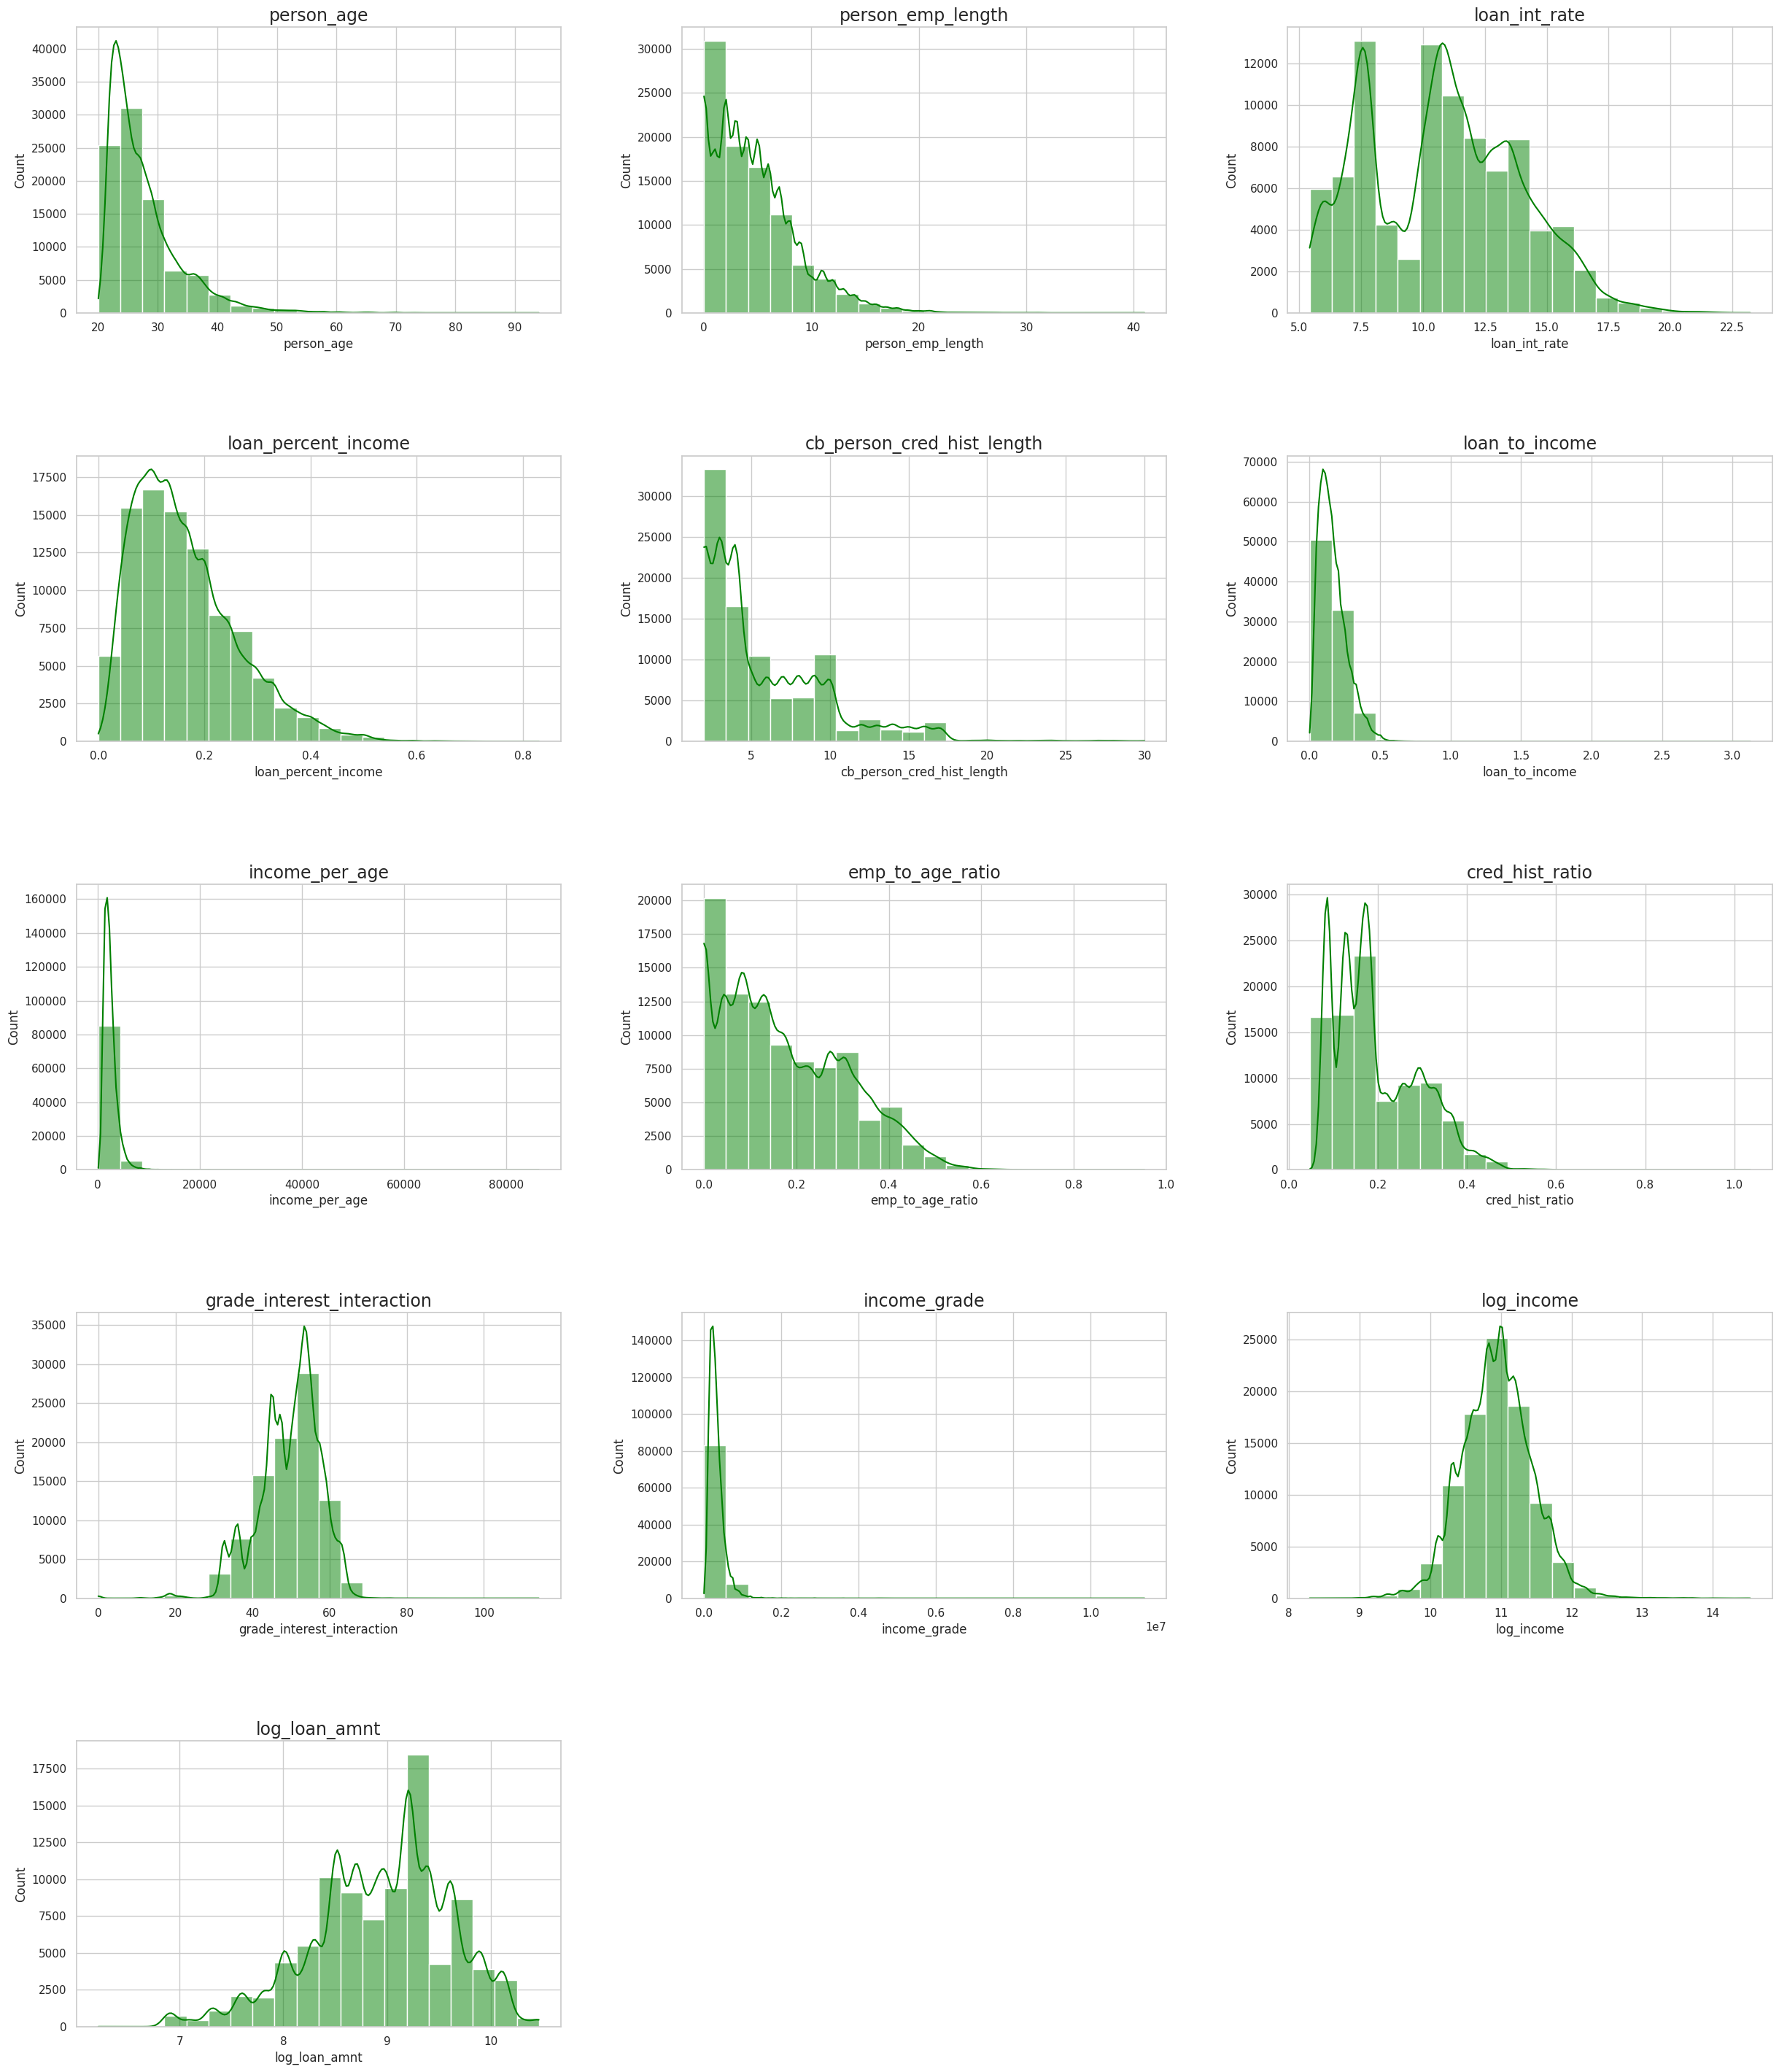

In [553]:
#visualize numerical data
plt.figure(figsize=(30,150))
plt.subplots_adjust(hspace=0.5, wspace=0.25)
for n, col in enumerate(list(numerical_after)):
    plt.subplot(20,3,n+1)
    sns.histplot(df_dropped[col], bins=20,color='green', kde=True)
    plt.title(col, fontsize=17)
plt.show()

In [554]:
skewness = df_dropped[list(numerical_after)].skew().sort_values(ascending=False)
skewness

income_grade                  9.577137
income_per_age                8.256704
person_age                    1.924875
cb_person_cred_hist_length    1.633585
loan_to_income                1.557229
person_emp_length             1.229770
loan_percent_income           1.014461
cred_hist_ratio               0.775116
emp_to_age_ratio              0.576042
loan_int_rate                 0.215482
log_income                    0.162390
log_loan_amnt                -0.455768
grade_interest_interaction   -0.829590
dtype: float64

High skew (skew > 1 lub < -1) → RobustScaler, might be outliers

low skew (skew ~ -1 … 1) → StandardScaler, symmetrical distribution

#### Robust and standard scaler

In [555]:
cols_to_robust = ['income_grade','income_per_age','loan_to_income']
cols_to_standard = ['person_age','cb_person_cred_hist_length','person_emp_length','loan_percent_income','cred_hist_ratio','emp_to_age_ratio','loan_int_rate','log_income','log_loan_amnt','grade_interest_interaction']

In [556]:
robust = RobustScaler()
robust.fit(df_dropped[cols_to_robust])

df_dropped[cols_to_robust] = robust.transform(df_dropped[cols_to_robust])
df_dropped[cols_to_robust]  = robust.transform(df_dropped[cols_to_robust])

In [557]:
standard = StandardScaler()
standard.fit(df_dropped[cols_to_standard])

df_dropped[cols_to_standard] = standard.transform(df_dropped[cols_to_standard])
df_dropped[cols_to_standard]  = standard.transform(df_dropped[cols_to_standard])

In [558]:
df_dropped.head()

,id,person_age,person_emp_length,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,loan_to_income,income_per_age,...,grade_interest_interaction,income_grade,log_income,log_loan_amnt,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,0,-4.282117,-1.507922,-3.455287,-0.952949,0,-0.936617,0,0.628711,-1.490672,...,-6.081351,-1.334857,-23.894582,-13.934703,False,True,False,False,False,False
1,1,-4.686899,-1.119181,-3.256189,-11.476951,0,-1.672558,0,-5.479546,-1.489878,...,-6.144769,-1.334856,-22.003886,-14.844051,False,False,False,True,False,False
2,2,-4.498001,-0.989601,-3.732527,3.256651,0,-1.181930,0,2.882949,-1.490648,...,-6.144769,-1.334857,-24.678896,-13.934703,False,False,False,False,True,False
3,3,-4.471015,-0.600860,-3.495963,-0.952949,0,-1.488573,0,0.628711,-1.489983,...,-6.111103,-1.334853,-21.106235,-12.380030,False,False,False,False,False,True
4,4,-4.686899,-1.378342,-3.944470,-8.319750,0,-1.611229,0,-3.734329,-1.489788,...,-6.330797,-1.334852,-21.726345,-13.934703,False,False,False,True,False,False


## 4. Multicolinearity

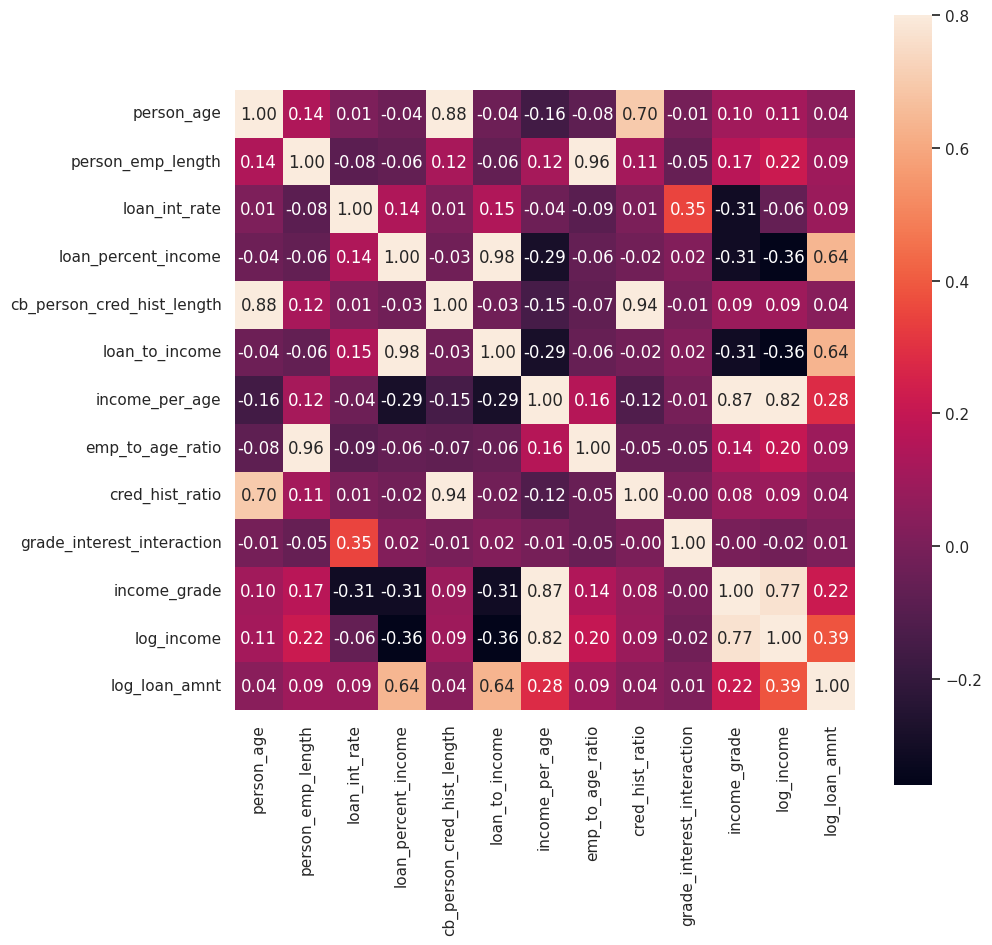

In [559]:
#numerical correlations matrix
new_corr_matrix = df_dropped.drop(['id',], axis=1).select_dtypes(include='number').corr()

plt.figure(figsize=(10, 10))
sns.heatmap(new_corr_matrix, vmax=.8, square=True, annot=True, fmt='.2f')
plt.show()

In [560]:
abs_new_corr_matrix = new_corr_matrix.abs()

In [561]:
np.fill_diagonal(abs_new_corr_matrix.values, 0)

In [562]:
threshold = 0.83

high_corr_pairs = [(col1, col2) for col1 in abs_new_corr_matrix.columns 
                   for col2 in abs_new_corr_matrix.columns 
                   if abs_new_corr_matrix.loc[col1, col2] > threshold and col1 < col2]

print("highly correlated pairs:")
for pair in high_corr_pairs:
    print(pair, "->", abs_new_corr_matrix.loc[pair[0], pair[1]])

highly correlated pairs:
('loan_percent_income', 'loan_to_income') -> 0.9819230305136497
('cb_person_cred_hist_length', 'person_age') -> 0.8767732123445114
('cb_person_cred_hist_length', 'cred_hist_ratio') -> 0.9402144859296441
('emp_to_age_ratio', 'person_emp_length') -> 0.9552325967261095
('income_grade', 'income_per_age') -> 0.8691176447520631


In [563]:
multicolinearity_to_drop_cols = ['loan_percent_income','cb_person_cred_hist_length','person_emp_length','income_grade']

In [564]:
df_dropped.shape

(91216, 28)

In [565]:
df_train_final = df_dropped.drop(multicolinearity_to_drop_cols, axis=1)
df_train_final = df_train_final.drop('id', axis=1)
df_train_final.shape

(91216, 23)

In [566]:
df_train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91216 entries, 0 to 91225
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   person_age                     91216 non-null  float64 
 1   loan_int_rate                  91216 non-null  float64 
 2   cb_person_default_on_file      91216 non-null  category
 3   loan_status                    91216 non-null  category
 4   loan_to_income                 91216 non-null  float64 
 5   income_per_age                 91216 non-null  float64 
 6   high_loan_burden               91216 non-null  category
 7   emp_to_age_ratio               91216 non-null  float64 
 8   young_high_loan                91216 non-null  category
 9   cred_hist_ratio                91216 non-null  float64 
 10  thin_credit_history            91216 non-null  category
 11  had_default                    91216 non-null  category
 12  home_stability                 91216 

# Model development

In [567]:
knn_class = KNeighborsClassifier()
tree_class = DecisionTreeClassifier()
forest_class = RandomForestClassifier()
svc_class = SVC()
ada_class = AdaBoostClassifier()
sgd_class = SGDClassifier()
ridge_class = RidgeClassifier()
log_class = LogisticRegression()
linSVC_class = LinearSVC()
gbc_class = GradientBoostingClassifier()
xgb_class = XGBClassifier(enable_categorical=True)
lgbm_class = LGBMClassifier(verbosity=-1)
cat_class = CatBoostClassifier(verbose=0)
models_list = {'CatBoost_Classifier':cat_class,
               'KNeighbors_Regression':knn_class,
               'Decision_Tree':tree_class, 
               'Random_Forest':forest_class,
               'AdaBoost_Classifier': ada_class,
               'SVC_Classifier':svc_class,
               'SGD_Classifier':sgd_class, 
               'Ridge_Classification':ridge_class,
               'Logistic_Regression':log_class, 
               'LinearSVC':linSVC_class,
               'GradientBoosting_Classification':gbc_class, 
               'XGBoost_Classification':xgb_class, 
               'LightGBM_Classification':lgbm_class}

In [568]:
df_results = pd.DataFrame(columns=['model','cv_method','basic_roc_auc','roc_auc_mean','roc_auc_std','parameters'])

eval_methods = ['cross_val_score',
                'kfold',
                'repeatedkfold',
                'stratifiedkfold',
                'shufflesplit']

dataframes_dict = {'df_train_final': df_train_final}   

In [569]:
#pisane pod catboost
def basic_models(df_results, datasetname, models, cv_method, features_train, target_train, cat_cols):
    from sklearn.model_selection import cross_val_score, KFold, RepeatedKFold, StratifiedKFold, ShuffleSplit
    from sklearn.metrics import roc_auc_score
    import numpy as np
    import pandas as pd
    from catboost import CatBoostClassifier

    scoring = 'roc_auc'
    cv = 10
    df_final = df_results.copy()
    for key, model in models.items():

        if cv_method == 'cross_val_score':
            train_X, test_X, train_y, test_y = train_test_split(features_train, target_train, test_size=0.2, random_state=1)
            if isinstance(model, CatBoostClassifier):
                tm = model.fit(train_X, train_y, cat_features=cat_cols, verbose=0)
                kf = KFold(n_splits=10, shuffle=True, random_state=1)
                scores = []
                for tr_idx, te_idx in kf.split(train_X):
                    X_tr, X_te = train_X.iloc[tr_idx], train_X.iloc[te_idx]
                    y_tr, y_te = train_y.iloc[tr_idx], train_y.iloc[te_idx]
                    tmp_model = CatBoostClassifier(**model.get_params())
                    tmp_model.fit(X_tr, y_tr, cat_features=cat_cols, verbose=0)
                    y_pred = tmp_model.predict(X_te)
                    scores.append(roc_auc_score(y_te, y_pred))
                score = np.array(scores)
            else:
                tm = model.fit(train_X, train_y)
                score = cross_val_score(model, train_X, train_y, scoring=scoring, cv=cv)
            tm_predict = tm.predict(test_X)
            prediction = roc_auc_score(test_y, tm_predict)
            df_created = pd.DataFrame({
                'datasetname': datasetname,
                'model': key,
                'cv_method': cv_method,
                'basic_roc_auc': [prediction],
                'roc_auc_mean': score.mean(),
                'roc_auc_std': score.std(),
                'parameters': 'None'
            })
            df_full_results = pd.concat([df_results, df_created], axis=0, ignore_index=True)

        if cv_method == 'kfold':
            predictions = []
            accu = []
            kf = KFold(n_splits=10, shuffle=True, random_state=12)
            for train_index, test_index in kf.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                if isinstance(model, CatBoostClassifier):
                    tm = model.fit(train_X, train_y, cat_features=cat_cols, verbose=0)
                else:
                    tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = roc_auc_score(test_y, tm_predict)
                accu.append(prediction)
                predictions.append(prediction)
                df_created = pd.DataFrame({
                    'datasetname': datasetname,
                    'model': key,
                    'cv_method': cv_method,
                    'basic_roc_auc': [np.max(predictions)],
                    'roc_auc_mean': np.mean(accu),
                    'roc_auc_std': np.std(accu),
                    'parameters': 'None'
                })
                df_full_results = pd.concat([df_results, df_created], axis=0, ignore_index=True)

        if cv_method == 'repeatedkfold':
            predictions = []
            accu = []
            rkf = RepeatedKFold(n_splits=10, random_state=12)
            for train_index, test_index in rkf.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                if isinstance(model, CatBoostClassifier):
                    tm = model.fit(train_X, train_y, cat_features=cat_cols, verbose=0)
                else:
                    tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = roc_auc_score(test_y, tm_predict)
                accu.append(prediction)
                predictions.append(prediction)
                df_created = pd.DataFrame({
                    'datasetname': datasetname,
                    'model': key,
                    'cv_method': cv_method,
                    'basic_roc_auc': [np.max(predictions)],
                    'roc_auc_mean': np.mean(accu),
                    'roc_auc_std': np.std(accu),
                    'parameters': 'None'
                })
                df_full_results = pd.concat([df_results, df_created], axis=0, ignore_index=True)

        if cv_method == 'stratifiedkfold':
            predictions = []
            accu = []
            skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=12)
            for train_index, test_index in skf.split(features_train, target_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                if isinstance(model, CatBoostClassifier):
                    tm = model.fit(train_X, train_y, cat_features=cat_cols, verbose=0)
                else:
                    tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = roc_auc_score(test_y, tm_predict)
                accu.append(prediction)
                predictions.append(prediction)
                df_created = pd.DataFrame({
                    'datasetname': datasetname,
                    'model': key,
                    'cv_method': cv_method,
                    'basic_roc_auc': [np.max(predictions)],
                    'roc_auc_mean': np.mean(accu),
                    'roc_auc_std': np.std(accu),
                    'parameters': 'None'
                })
                df_full_results = pd.concat([df_results, df_created], axis=0, ignore_index=True)

        if cv_method == 'shufflesplit':
            predictions = []
            accu = []
            shs = ShuffleSplit(n_splits=10, test_size=0.2, random_state=12)
            for train_index, test_index in shs.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                if isinstance(model, CatBoostClassifier):
                    tm = model.fit(train_X, train_y, cat_features=cat_cols, verbose=0)
                else:
                    tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = roc_auc_score(test_y, tm_predict)
                accu.append(prediction)
                predictions.append(prediction)
                df_created = pd.DataFrame({
                    'datasetname': datasetname,
                    'model': key,
                    'cv_method': cv_method,
                    'basic_roc_auc': [np.max(predictions)],
                    'roc_auc_mean': np.mean(accu),
                    'roc_auc_std': np.std(accu),
                    'parameters': 'None'
                })
                df_full_results = pd.concat([df_results, df_created], axis=0, ignore_index=True)
        print(f'done model: {key}')
        df_row = pd.DataFrame({
            'datasetname': [df_full_results.loc[0]['datasetname']],
            'model': [df_full_results.loc[0]['model']],
            'cv_method': [df_full_results.loc[0]['cv_method']],
            'basic_roc_auc': [df_full_results['basic_roc_auc'].mean()],
            'roc_auc_mean': [df_full_results.loc[0]['roc_auc_mean']],
            'roc_auc_std': [df_full_results.loc[0]['roc_auc_std']],
            'parameters': 'None'
        })
        df_final = pd.concat([df_final, df_row], axis=0, ignore_index=True)
    return df_final

In [570]:
def train_models(df_results, dataframes_dict, eval_methods, models_list, cat_cols):

    final_result = []

    for key,value in dataframes_dict.items():
        features_train = value.drop('loan_status', axis=1)
        target_train = value['loan_status']
        print(f'training data: {key}')
        for method in eval_methods:
            print(f'training method: {method}')
            result = basic_models(df_results,key, models_list, method, features_train, target_train, cat_cols)
            final_result.append(result)
            print('done method')
        print('done data')

    final_data_of_trained_models = pd.concat(final_result, axis=0)
    return final_data_of_trained_models

In [571]:
cat_cols = df_train_final.select_dtypes(include='category').drop('loan_status', axis=1).columns.tolist()
print(cat_cols)

['cb_person_default_on_file', 'high_loan_burden', 'young_high_loan', 'thin_credit_history', 'had_default', 'home_stability', 'loan_grade_num']


In [572]:
#df_models_trained = train_models(df_results,dataframes_dict,eval_methods,models_list, cat_cols)

In [573]:
#df_models_trained.to_csv('./v2_trained_basic_models.csv')

In [574]:
df_models_trained= pd.read_csv('../v2_trained_basic_models.csv', index_col=0)

In [575]:
df_models_trained

,model,cv_method,basic_roc_auc,roc_auc_mean,roc_auc_std,parameters,datasetname
0,CatBoost_Classifier,cross_val_score,0.864606,0.862665,0.005486,NaN,df_train_final
1,KNeighbors_Regression,cross_val_score,0.739893,0.842249,0.005350,NaN,df_train_final
2,Decision_Tree,cross_val_score,0.843617,0.843206,0.006113,NaN,df_train_final
3,Random_Forest,cross_val_score,0.859022,0.937905,0.005759,NaN,df_train_final
4,AdaBoost_Classifier,cross_val_score,0.805682,0.908345,0.005610,NaN,df_train_final
...,...,...,...,...,...,...,...
8,Logistic_Regression,shufflesplit,0.781533,0.768951,0.005259,NaN,df_train_final
9,LinearSVC,shufflesplit,0.774856,0.764243,0.004076,NaN,df_train_final
10,GradientBoosting_Classification,shufflesplit,0.857335,0.851841,0.003126,NaN,df_train_final
11,XGBoost_Classification,shufflesplit,0.866871,0.862750,0.003447,NaN,df_train_final


In [576]:
df_models_trained.sort_values(by='roc_auc_mean', ascending=False).head(30)

,model,cv_method,basic_roc_auc,roc_auc_mean,roc_auc_std,parameters,datasetname
12,LightGBM_Classification,cross_val_score,0.860824,0.954783,0.004438,NaN,df_train_final
11,XGBoost_Classification,cross_val_score,0.866169,0.954421,0.004056,NaN,df_train_final
3,Random_Forest,cross_val_score,0.859022,0.937905,0.005759,NaN,df_train_final
10,GradientBoosting_Classification,cross_val_score,0.856840,0.936039,0.005639,NaN,df_train_final
4,AdaBoost_Classifier,cross_val_score,0.805682,0.908345,0.005610,NaN,df_train_final
8,Logistic_Regression,cross_val_score,0.773566,0.895861,0.005617,NaN,df_train_final
9,LinearSVC,cross_val_score,0.766799,0.895554,0.005682,NaN,df_train_final
5,SVC_Classifier,cross_val_score,0.733674,0.893404,0.004841,NaN,df_train_final
7,Ridge_Classification,cross_val_score,0.730828,0.892367,0.005885,NaN,df_train_final
6,SGD_Classifier,cross_val_score,0.806197,0.882204,0.006263,NaN,df_train_final


# Tuning models with Optuna

In [577]:
final_train_features = df_train_final.drop('loan_status',axis=1)
final_train_target = df_train_final['loan_status']

### LGBM

In [578]:
def objective_lgbm_class(trial):
    n_estimators = trial.suggest_int('n_estimators',100,1000)
    learning_rate = trial.suggest_uniform('learning_rate',0.01,0.1)
    max_depth = trial.suggest_int('max_depth',3,15)
    num_leaves = trial.suggest_int('num_leaves',31,255)
    min_child_samples = trial.suggest_int('min_child_samples',10,100)
    subsample  = trial.suggest_uniform('subsample',0.5,1.0)
    colsample_bytree  = trial.suggest_uniform('colsample_bytree',0.5,1.0)
    lambda_l1   = trial.suggest_uniform('lambda_l1',0.0,10.0)
    lambda_l2  = trial.suggest_uniform('lambda_l2',0.0,10.0)
    min_split_gain   = trial.suggest_uniform('min_split_gain',0.0,1.0)
    boosting_type  = trial.suggest_categorical('boosting_type', ["gbdt", "dart", "goss"])
    early_stopping_rounds  = trial.suggest_int('early_stopping_rounds',10,100)

    model = LGBMClassifier(n_estimators=n_estimators,
                              learning_rate=learning_rate,
                              max_depth=max_depth,
                              num_leaves=num_leaves,
                              min_child_samples=min_child_samples,
                              subsample=subsample,
                              colsample_bytree=colsample_bytree,
                              lambda_l1=lambda_l1,
                              lambda_l2=lambda_l2,
                              min_split_gain=min_split_gain,
                              boosting_type=boosting_type,
                              early_stopping_rounds=early_stopping_rounds,
                              max_bin= 5000,
                              verbosity=-1)

    X_train, X_val, y_train, y_val = train_test_split(final_train_features, final_train_target, test_size=0.4, random_state=42)

    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

    y_pred = model.predict_proba(X_val)[:,1]
    score = roc_auc_score(y_val, y_pred)
    
    return score

In [579]:
study_lgbm_class = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=12))

In [580]:
#study_lgbm_class.optimize(objective_lgbm_class, n_trials=100,  show_progress_bar=False)

In [581]:
#params_lgbm_class = study_lgbm_class.best_params
#params_lgbm_class

### XGBOOST

In [582]:
def objective_xgb_class(trial):

    model = XGBClassifier(
        max_depth=trial.suggest_int('max_depth', 3, 10),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 7),
        gamma=trial.suggest_float('gamma', 0.0, 1.0),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 0.0, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 1.0, 5.0),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.3, 1.0),
        colsample_bylevel=trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        colsample_bynode=trial.suggest_float('colsample_bynode', 0.5, 1.0),
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        tree_method="hist",  
        early_stopping_rounds=trial.suggest_int('early_stopping_rounds', 10, 100),
        verbosity=0,           
        max_bin=5000,
        enable_categorical=True
    )

    X_train, X_val, y_train, y_val = train_test_split(
        final_train_features,
        final_train_target,
        test_size=0.4,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False                    
    )

    y_pred = model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, y_pred)

    return score

In [583]:
study_xgb_class = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=12))

In [584]:
#study_xgb_class.optimize(objective_xgb_class, n_trials=100, show_progress_bar=False)

In [585]:
#params_xgb_class = study_xgb_class.best_params
#params_xgb_class

# Train models with hyperparameters

In [586]:
lgbm_params = {
    'n_estimators': 683,
    'learning_rate': 0.09577369020051105,
    'max_depth': 9,
    'num_leaves': 38,
    'min_child_samples': 23,
    'subsample': 0.6645350870995245,
    'colsample_bytree': 0.9746990579659399,
    'lambda_l1': 1.0351346602919231,
    'lambda_l2': 6.992697757197954,
    'min_split_gain': 0.8945747495860352,
    'boosting_type': 'goss',
    'early_stopping_rounds': 43,
    'max_bin': 5000,
    'verbosity': -1
}

xgb_params = {
    'max_depth': 5,
    'min_child_weight': 2,
    'gamma': 0.33822134312176944,
    'subsample': 0.9500322606965119,
    'reg_alpha': 0.6712213483349332,
    'reg_lambda': 1.414801091250681,
    'learning_rate': 0.07726359727972147,
    'colsample_bytree': 0.954870631444895,
    'colsample_bylevel': 0.9234226139249676,
    'colsample_bynode': 0.9095762611565754,
    'n_estimators': 602,
    'early_stopping_rounds': 46,
    'verbosit':0,           
    'max_bin':5000,
    'enable_categorical':True
}

In [587]:
X_train, X_val, y_train, y_val = train_test_split(final_train_features, final_train_target, test_size=0.4, random_state=42)

In [588]:
lgbm_model_params = LGBMClassifier(**lgbm_params)
xgboost_model_params = XGBClassifier(**xgb_params)

In [589]:
lgbm_model_params.fit(X_train, y_train, eval_set=[(X_val, y_val)])

LGBMClassifier(boosting_type='goss', colsample_bytree=0.9746990579659399,
               early_stopping_rounds=43, lambda_l1=1.0351346602919231,
               lambda_l2=6.992697757197954, learning_rate=0.09577369020051105,
               max_bin=5000, max_depth=9, min_child_samples=23,
               min_split_gain=0.8945747495860352, n_estimators=683,
               num_leaves=38, subsample=0.6645350870995245, verbosity=-1)

In [590]:
xgboost_model_params.fit(X_train, y_train, eval_set=[(X_val, y_val)],verbose=False )

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.9234226139249676,
              colsample_bynode=0.9095762611565754,
              colsample_bytree=0.954870631444895, device=None,
              early_stopping_rounds=46, enable_categorical=True,
              eval_metric=None, feature_types=None, gamma=0.33822134312176944,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07726359727972147,
              max_bin=5000, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=602, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

# Prepare test set

In [591]:
df_test_copy.isna().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

### 1. Add new features

In [592]:
def feature_adder(df):
    #new features
    df["loan_to_income"] = df["loan_amnt"] / df["person_income"]
    df["income_per_age"] = df["person_income"] / df["person_age"]
    df["high_loan_burden"] = (df["loan_percent_income"] > 0.3).astype(int)
    df["emp_to_age_ratio"] = df["person_emp_length"] / df["person_age"]
    df["young_high_loan"] = ((df["person_age"] < 25) & (df["loan_percent_income"] > 0.4)).astype(int)
    df["cred_hist_ratio"] = (df["cb_person_cred_hist_length"] / df["person_age"])
    df["thin_credit_history"] = (df["cb_person_cred_hist_length"] < 3).astype(int)
    df["had_default"] = (df["cb_person_default_on_file"] == "Y").astype(int)
   
    #ordinal encoding
    home_map = {"OWN": 3, "MORTGAGE": 2, "RENT": 1, "OTHER": 0}
    df["home_stability"] = df["person_home_ownership"].map(home_map)
    
    grade_map = {"A": 6, "B": 5, "C": 4, "D": 3, "E": 2, "F": 1, "G": 0}
    df["loan_grade_num"] = df["loan_grade"].map(grade_map)

    #for trees models
    df["grade_interest_interaction"] = (df["loan_grade_num"] * df["loan_int_rate"])
    df["income_grade"] = (df["person_income"] * df["loan_grade_num"])

    #transformations
    df["log_income"] = np.log1p(df["person_income"])
    df["log_loan_amnt"] = np.log1p(df["loan_amnt"])

    return df

### 2. Columnt type transforming

In [593]:
def type_transformer(df):
    for col in df.select_dtypes(include='number'):
        if df[col].nunique() <= 25:
            df[col] = df[col].astype('category')
    
    object_cols = df.select_dtypes(include='object').columns
    df[object_cols] = df[object_cols].astype('category')

    return df

### 3. Feature encoding

In [594]:
def df_encoder(df):
    #onehot
    df_encoded = pd.get_dummies(df, columns=['loan_intent'], drop_first=False)
    #encode labels
    df_encoded['cb_person_default_on_file'] = df_encoded['cb_person_default_on_file'].map({'N': 0, 'Y': 1})
    #columns drop
    df_dropped = df_encoded.drop(['loan_grade','person_home_ownership', 'person_income', 'loan_amnt'], axis=1)

    return df_dropped

### 4. Feature scaling

In [595]:
def df_scaler(df):
    cols_to_robust = ['income_grade','income_per_age','loan_to_income']
    cols_to_standard = ['person_age','cb_person_cred_hist_length','person_emp_length','loan_percent_income','cred_hist_ratio','emp_to_age_ratio','loan_int_rate','log_income','log_loan_amnt','grade_interest_interaction']

    robust = RobustScaler()
    robust.fit(df[cols_to_robust])
    
    df[cols_to_robust] = robust.transform(df[cols_to_robust])
    df[cols_to_robust]  = robust.transform(df[cols_to_robust])

    standard = StandardScaler()
    standard.fit(df[cols_to_standard])
    
    df[cols_to_standard] = standard.transform(df[cols_to_standard])
    df[cols_to_standard]  = standard.transform(df[cols_to_standard])

    return df

### 5. Multicol Drop

In [596]:
def multicol_dropper(df):
    df_dropped = df.drop(['loan_percent_income','cb_person_cred_hist_length','person_emp_length','income_grade','id'], axis=1)
    return df_dropped

### 6. Final test set

In [597]:
transformation_pipeline = Pipeline([('feature_adder', FunctionTransformer(feature_adder, validate=False)),
                        ('type_transformer', FunctionTransformer(type_transformer, validate=False)),
                        ('df_encoder', FunctionTransformer(df_encoder, validate=False)),
                        ('df_scaler', FunctionTransformer(df_scaler, validate=False)),
                        ('multicol_dropper', FunctionTransformer(multicol_dropper, validate=False))])

In [598]:
transformed = transformation_pipeline.fit_transform(df_test_copy)

# Predictions

In [602]:
lgbm_predictions = lgbm_model_params.predict_proba(transformed)[:,1]

In [603]:
xgb_predictions = xgboost_model_params.predict_proba(transformed)[:,1]

In [604]:
lgbm_predictions

array([0.99747551, 0.04097431, 0.88469801, ..., 0.04522521, 0.90766173,
       0.99243594])

In [605]:
lgbm_output = pd.DataFrame({'id': df_test_copy.id,
                            'loan_status': lgbm_predictions})
lgbm_output.to_csv('lgbm_predictions.csv', index=False)

In [607]:
xgb_output = pd.DataFrame({'id': df_test_copy.id,
                            'loan_status': xgb_predictions})
xgb_output.to_csv('xgb_predictions.csv', index=False)

# SHAP

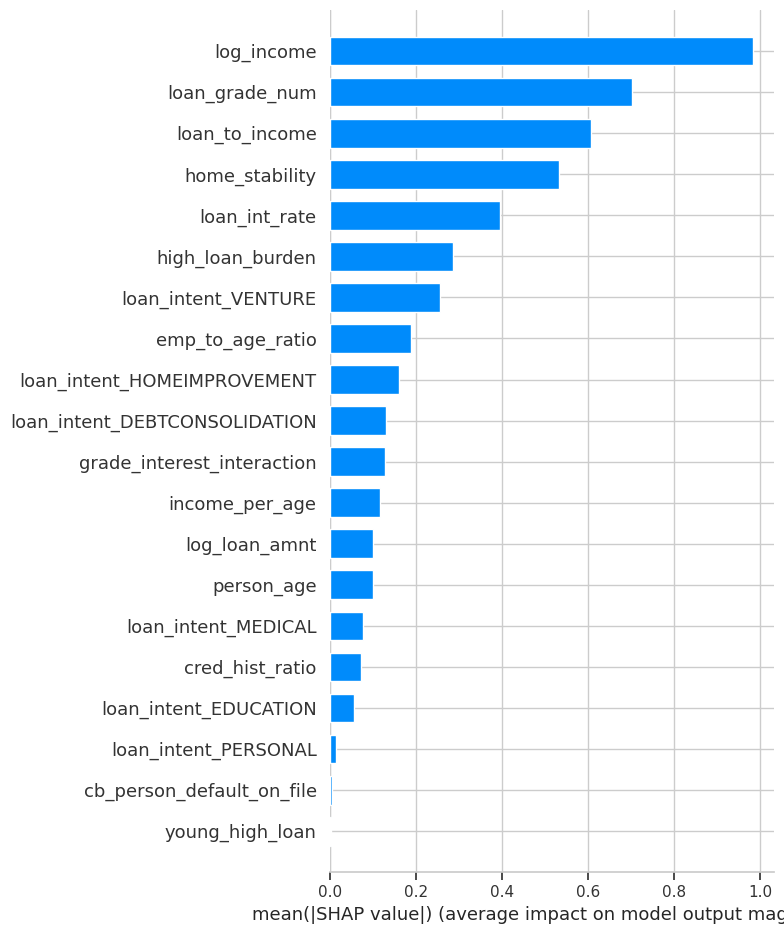

In [625]:
explainer = shap.TreeExplainer(
    lgbm_model_params,
    feature_perturbation="tree_path_dependent"
)

lgbm_shap_values = explainer.shap_values(X_val)

shap.summary_plot(lgbm_shap_values, X_val, plot_type="bar")

In [627]:
dtrain = xgb.DMatrix(X_train, enable_categorical=True)
dval = xgb.DMatrix(X_val, enable_categorical=True)

explainer = shap.TreeExplainer(xgboost_model_params.get_booster())
xgb_shap_values = explainer.shap_values(dval)

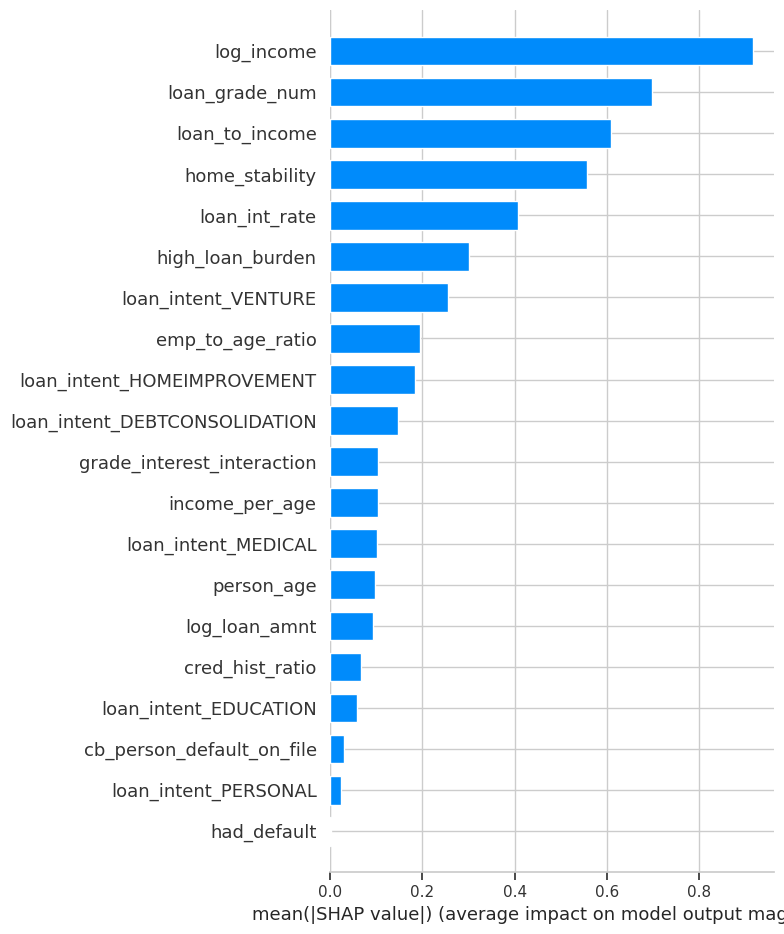

In [628]:
shap.summary_plot(xgb_shap_values, X_val, plot_type="bar")